# Carga de datos de precipitación sub-horaria

Esta notebook construye el conjunto de etiquetas de ground truth para el modelo de nowcasting. A partir de los registros de precipitación sub-horaria descargados de [`s54a-sgyg`](https://www.datos.gov.co/Ambiente-y-Desarrollo-Sostenible/Precipitaci-n/s54a-sgyg/about_data) para las 70 estaciones seleccionadas en 2024 y 2025, se agregan los datos a resolución horaria, se define el umbral 
operativo de lluvia fuerte, y se etiqueta cada hora como evento de lluvia fuerte (1) o no (0).

Los archivos CSV por estación se encuentran en `data/rainfall_subhourly/`, con tres columnas: `codigoestacion`, `fechaobservacion` y `valorobservado` (mm).

In [1]:
import requests
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

import os
import time
from datetime import datetime

## 1. Descarga

Los datos se descargan del dataset `s54a-sgyg` para las 70 estaciones seleccionadas en 2024 y 2025. El script descarga mes a mes por estación, guarda un log de combinaciones completadas para reanudar si se interrumpe, y almacena un CSV por estación en `data/rainfall_subhourly/`.

**Nota:** si los CSVs ya existen en `data/rainfall_subhourly/`, esta sección no necesita correrse de nuevo. Pasar directamente a la sección 2.

In [ ]:
# Configuración
URL_PRECIP = "https://www.datos.gov.co/resource/s54a-sgyg.json"
AÑOS = [2024, 2025]
MESES = range(1, 13)
PAUSA = 0.5  # segundos entre consultas
REINTENTOS = 3
LOG_FILE = "descarga_precipitacion_log.txt"
OUTPUT_DIR = r"..\..\data\rainfall_subhourly"

# Crear carpeta de salida
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Cargar log de combinaciones ya completadas
completados = set()
if os.path.exists(LOG_FILE):
    with open(LOG_FILE, 'r') as f:
        completados = set(line.strip() for line in f.readlines())
print(f"Combinaciones ya completadas: {len(completados)}")

# Cargar estaciones objetivo
df_anual = pd.read_csv('precipitacion_anual_candidatas.csv', dtype={'codigoestacion': str})
est_2024 = set(df_anual[df_anual['anio'] == 2024]['codigoestacion'])
est_2025 = set(df_anual[df_anual['anio'] == 2025]['codigoestacion'])
estaciones_objetivo = est_2024 | est_2025
print(f"Estaciones objetivo: {len(estaciones_objetivo)}")

# Función de descarga con reintentos
def descargar_mes(cod, año, mes):
    fecha_ini = f"{año}-{mes:02d}-01T00:00:00"
    if mes == 12:
        fecha_fin = f"{año}-12-31T23:59:59"
    else:
        fecha_fin = f"{año}-{mes+1:02d}-01T00:00:00"
    
    for intento in range(REINTENTOS):
        try:
            params = {
                "$where": f"codigoestacion='{cod}' AND fechaobservacion >= '{fecha_ini}' AND fechaobservacion < '{fecha_fin}'",
                "$order": "fechaobservacion ASC",
                "$limit": 50000
            }
            r = requests.get(URL_PRECIP, params=params, timeout=60)
            data = r.json()
            if isinstance(data, list):
                return data
        except Exception as e:
            print(f"  Intento {intento+1}/{REINTENTOS} fallido: {e}")
            time.sleep(2 ** intento)  # espera exponencial: 1, 2, 4 segundos
    return None

# Descarga principal
total = len(estaciones_objetivo) * len(AÑOS) * len(list(MESES))
procesados = 0

for cod in sorted(estaciones_objetivo):
    registros_estacion = []
    
    for año in AÑOS:
        # Solo descargar si la estación tiene datos ese año
        if año == 2024 and cod not in est_2024:
            continue
        if año == 2025 and cod not in est_2025:
            continue
        
        for mes in MESES:
            key = f"{cod}_{año}_{mes:02d}"
            procesados += 1
            
            if key in completados:
                print(f"[{procesados}/{total}] Ya completado: {key}")
                continue
            
            print(f"[{procesados}/{total}] Descargando: {key}...")
            data = descargar_mes(cod, año, mes)
            
            if data is None:
                print(f"  ERROR: no se pudo descargar {key} después de {REINTENTOS} intentos")
                continue
            
            if len(data) > 0:
                registros_estacion.extend(data)
                print(f"  OK: {len(data)} registros")
            else:
                print(f"  Sin datos")
            
            # Registrar en log
            with open(LOG_FILE, 'a') as f:
                f.write(key + '\n')
            
            time.sleep(PAUSA)
    
    # Guardar CSV por estación
    if registros_estacion:
        df_est = pd.DataFrame(registros_estacion)
        df_est = df_est[['codigoestacion', 'fechaobservacion', 'valorobservado']]
        df_est.to_csv(f"{OUTPUT_DIR}/{cod}.csv", index=False)
        print(f"  Guardado: {OUTPUT_DIR}/{cod}.csv ({len(df_est)} registros)")

print("\nDescarga completada.")

### 1.1 Verificación de la descarga

Como verificación de la descarga, se examinan los registros de la estación `0021201980 (Cerro Guadalupe)`, que sirve de referencia por haber sido validada previamente contra la visualización oficial del portal datos.gov.co.

La precipitación total anual es similar en ambos años (~564 mm en 2024 y ~552 mm en 2025), consistente con los totales reportados por la fuente original. La serie diaria muestra el patrón climatológico esperado para la Sabana de Bogotá: temporada seca en el primer semestre de 2024 (enero-agosto, coincidente con el final del episodio El Niño), un pico de actividad convectiva en el último trimestre de 2024 con un evento extremo de ~170 mm el 4 de noviembre, y una distribución más uniforme a lo largo de 2025. La descarga se considera verificada.

   anio  valorobservado
0  2024           564.1
1  2025           552.8


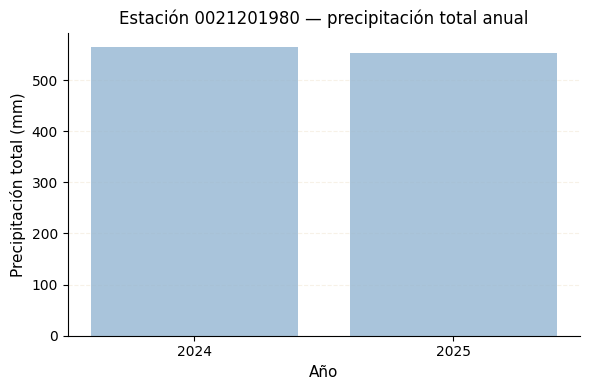

In [33]:
df_test = pd.read_csv(r'..\..\data\rainfall_subhourly\0021201980.csv')  #  
df_test['fechaobservacion'] = pd.to_datetime(df_test['fechaobservacion'])
df_test['anio'] = df_test['fechaobservacion'].dt.year
df_test['valorobservado'] = pd.to_numeric(df_test['valorobservado'])

precip_anual = df_test.groupby('anio')['valorobservado'].sum().reset_index()
print(precip_anual)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(precip_anual['anio'], precip_anual['valorobservado'], color='#94B6D2', alpha=0.8)
ax.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
ax.set_axisbelow(True)
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Precipitación total (mm)', fontsize=11)
ax.set_title('Estación 0021201980 — precipitación total anual', fontsize=12)
ax.set_xticks([2024, 2025])
plt.tight_layout()
plt.show()

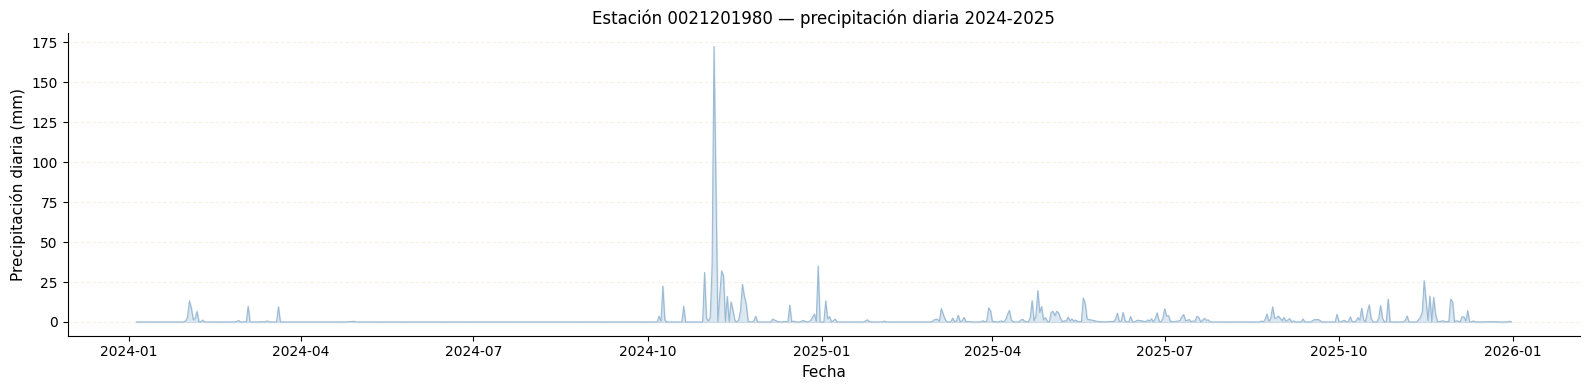

In [34]:
precip_diaria = df_test.groupby(df_test['fechaobservacion'].dt.date)['valorobservado'].sum().reset_index()
precip_diaria.columns = ['fecha', 'precip_mm']
precip_diaria['fecha'] = pd.to_datetime(precip_diaria['fecha'])

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(precip_diaria['fecha'], precip_diaria['precip_mm'], 
        color='#94B6D2', linewidth=0.8, alpha=0.9)
ax.fill_between(precip_diaria['fecha'], precip_diaria['precip_mm'], 
                alpha=0.3, color='#94B6D2')
ax.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
ax.set_axisbelow(True)
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Precipitación diaria (mm)', fontsize=11)
ax.set_title('Estación 0021201980 — precipitación diaria 2024-2025', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Selección de estaciones

De las 70 estaciones descargadas, no todas tienen cobertura temporal suficiente para ser útiles en el entrenamiento y validación del modelo. Se aplica un control de calidad en dos pasos: primero, se evalúa la cobertura temporal de cada estación medida como el rango entre el primer y el último registro disponible; segundo, se evalúa la densidad de registros en ese período para detectar estaciones con transmisión irregular o gaps significativos.

**Nota:** si el CSV `estaciones_ground_truth.csv` ya existe, esta segunda sección no necesita correrse de nuevo. Pasar directamente a la sección 3. Control de Calidad.

In [ ]:
# Ver tamaño de cada CSV
resumen_csvs = []
for archivo in sorted(os.listdir(r'..\..\data\rainfall_subhourly')):
    if archivo.endswith('.csv'):
        df = pd.read_csv(r'..\..\data\rainfall_subhourly\\' + archivo, 
                         dtype={'codigoestacion': str})
        resumen_csvs.append({
            'estacion': archivo.replace('.csv', ''),
            'n_registros': len(df),
            'fecha_min': df['fechaobservacion'].min(),
            'fecha_max': df['fechaobservacion'].max()
        })

df_resumen = pd.DataFrame(resumen_csvs)
print(df_resumen.sort_values('n_registros').to_string())

### 2.1 Cobertura temporal

El análisis revela dos grupos claramente diferenciados. Un primer grupo de 53 estaciones tiene cobertura de al menos 23 meses (enero 2024 a diciembre 2025), con conteos superiores a 350,000 registros. Un segundo grupo de 17 estaciones tiene cobertura parcial, con inicio entre abril de 2024 y octubre de 2025, y finalización en su mayoría en diciembre de 2025.

Dentro del grupo de cobertura parcial se aplican los siguientes criterios de exclusión:

- **Cobertura inferior a 6 meses o densidad de registros insuficiente:** se excluyen las estaciones `0021206990` (268 registros, 10 días en septiembre 2024), `2120000104` (71,486 registros, octubre-diciembre 2025) y `0021206980` (31,417 registros, mayo-diciembre 2025). Las dos primeras no capturan ningún ciclo estacional completo; la tercera, aunque tiene 7 meses de datos, presenta una densidad de registros inferior a la mitad de lo esperado para ese período, lo que indica gaps significativos en la transmisión.

- **Cobertura entre 12 y 22 meses:** las 14 estaciones restantes serán evaluadas en la siguiente sección mediante su densidad de registros. Si la densidad es suficiente, se conservan como candidatas al conjunto de prueba, dado que su inicio tardío en 2024 limita su utilidad para el entrenamiento pero no para la evaluación.

Estaciones con cobertura parcial (<23 meses): 17


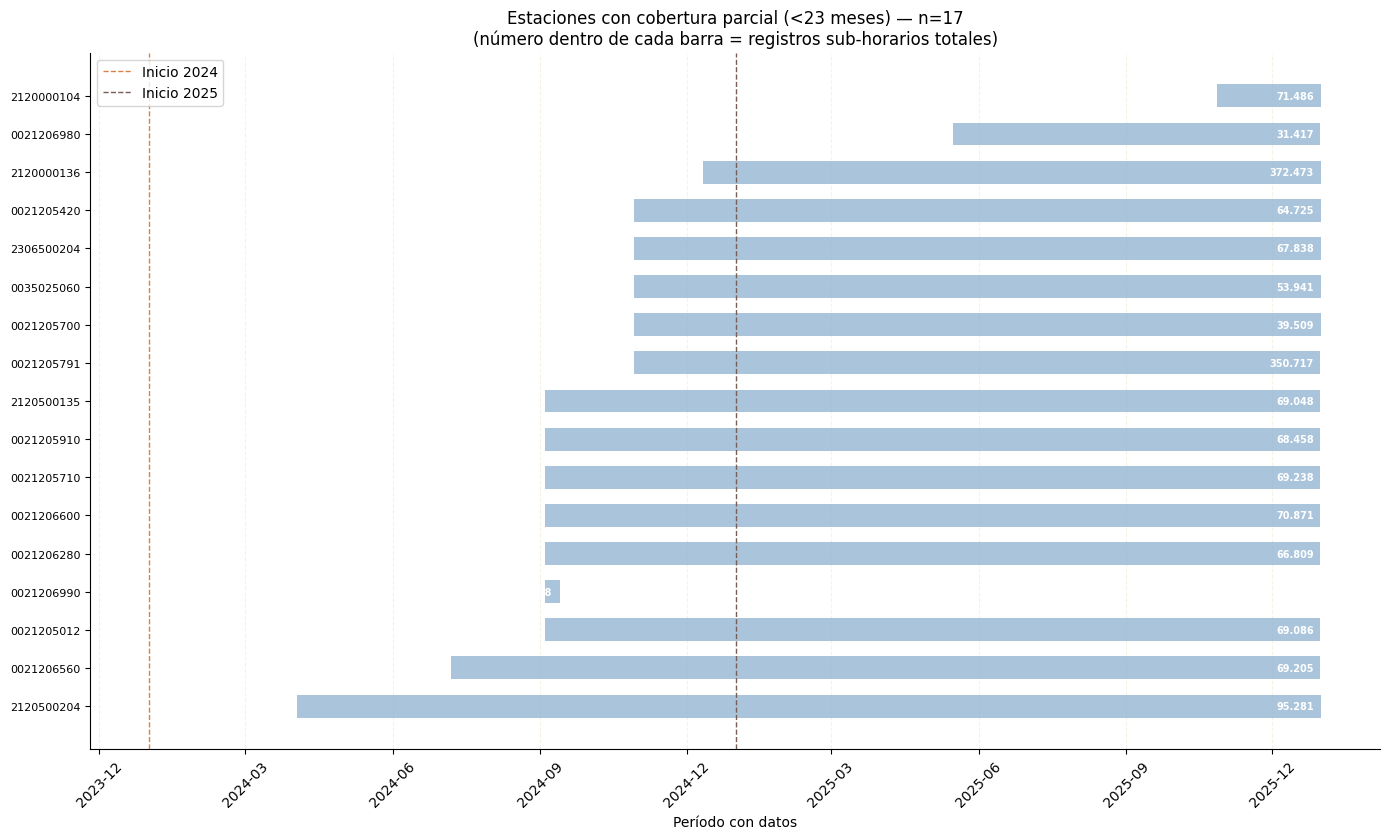

In [ ]:
# Registros subhorarios para estaciones con cubrimiento menor a 24 meses
df_resumen['fecha_min'] = pd.to_datetime(df_resumen['fecha_min'])
df_resumen['fecha_max'] = pd.to_datetime(df_resumen['fecha_max'])
df_resumen['duracion_meses'] = ((df_resumen['fecha_max'] - df_resumen['fecha_min']).dt.days / 30.44).round(1)

# Solo estaciones con menos de 24 meses
df_plot_parcial = df_resumen[df_resumen['duracion_meses'] < 23].sort_values('fecha_min').reset_index(drop=True)
print(f"Estaciones con cobertura parcial (<23 meses): {len(df_plot_parcial)}")

fig, ax = plt.subplots(figsize=(14, max(6, len(df_plot_parcial) * 0.5)))

for i, row in df_plot_parcial.iterrows():
    duracion = (row['fecha_max'] - row['fecha_min']).days
    ax.barh(i, duracion, left=row['fecha_min'], height=0.6,
            color='#94B6D2', alpha=0.8)
    
    ax.text(row['fecha_max'] - pd.Timedelta(days=5), i,
            f"{row['n_registros']:,}".replace(',', '.'),
            va='center', ha='right', fontsize=7, color='white',
            fontweight='bold')

ax.axvline(pd.Timestamp('2024-01-01'), color='#DD8047', linestyle='--', linewidth=1, label='Inicio 2024')
ax.axvline(pd.Timestamp('2025-01-01'), color='#775F55', linestyle='--', linewidth=1, label='Inicio 2025')

ax.set_yticks(range(len(df_plot_parcial)))
ax.set_yticklabels(df_plot_parcial['estacion'], fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.set_xlabel('Período con datos')
ax.set_title(f'Estaciones con cobertura parcial (<23 meses) — n={len(df_plot_parcial)}\n(número dentro de cada barra = registros sub-horarios totales)',
             fontsize=12)
ax.legend()
ax.yaxis.grid(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 2.2 Densidad de registros

La cobertura temporal no es suficiente por sí sola para garantizar la calidad de una estación: una estación puede tener un rango temporal amplio pero con gaps internos que reduzcan significativamente la información disponible. Para las 14 estaciones con cobertura parcial que superaron el filtro anterior, se calcula la densidad de registros que se define como el cociente entre los registros reales y los esperados según la cadencia mediana de transmisión de cada estación.

**Densidad por cobertura de referencia:** se compara el número de registros reales contra los esperados si la estación hubiera transmitido con la misma frecuencia mediana que las 53 estaciones con cobertura completa (~731 registros por día). Este primer análisis reveló que 12 de las 14 estaciones tienen densidades entre 12% y 22% — aparentemente muy bajas. Sin embargo, antes de excluirlas, se investigó la cadencia real de transmisión de cada estación.

**Densidad por cadencia real:** la cadencia mediana varía entre estaciones. La mayoría transmite cada 10 minutos, `0021205791` cada 2.2 minutos en promedio, y `2120000136` cada 1.3 minutos. Al recalcular los registros esperados usando la cadencia propia de cada estación, las densidades se reinterpretan completamente: hay 11 estaciones que parecían deficientes tienen en realidad densidades entre 87% y 110%, transmiten correctamente a 10 minutos y no a 2 minutos como la referencia global.

In [25]:
# Estaciones con cobertura parcial (excluidas las 3 ya descartadas)
excluir = ['0021206990', '2120000104', '0021206980']
df_parcial = df_resumen[
    (df_resumen['duracion_meses'] < 23) & 
    (~df_resumen['estacion'].isin(excluir))
].copy()

# Días de cobertura
df_parcial['dias_cobertura'] = (df_parcial['fecha_max'] - df_parcial['fecha_min']).dt.days

# Registros esperados según referencia de estaciones completas
registros_por_dia_referencia = df_resumen[df_resumen['duracion_meses'] >= 23]['n_registros'].median() / (24 * 30.44)
df_parcial['reg_esp_cobertura'] = (df_parcial['dias_cobertura'] * registros_por_dia_referencia).astype(int)
df_parcial['densidad_cobertura_pct'] = (df_parcial['n_registros'] / df_parcial['reg_esp_cobertura'] * 100).round(1)

# Cadencia real por estación
def estadisticas_cadencia(cod):
    try:
        df = pd.read_csv(f'..\\..\\data\\rainfall_subhourly\\{cod}.csv')
        df['fechaobservacion'] = pd.to_datetime(df['fechaobservacion'])
        df = df.sort_values('fechaobservacion')
        intervalos = df['fechaobservacion'].diff().dt.total_seconds() / 60
        intervalos = intervalos[(intervalos > 0) & (intervalos <= 60)]  # excluir outliers
        return intervalos.min(), intervalos.max(), intervalos.mean().round(1)
    except:
        return None, None, None

df_parcial[['cadencia_min', 'cadencia_max', 'cadencia_prom']] = df_parcial['estacion'].apply(
    lambda cod: pd.Series(estadisticas_cadencia(cod))
)

# Registros esperados según cadencia real
df_parcial['reg_esp_cadencia'] = (
    df_parcial['dias_cobertura'] * 24 * 60 / df_parcial['cadencia_prom']
).astype(int)
df_parcial['densidad_cadencia_pct'] = (
    df_parcial['n_registros'] / df_parcial['reg_esp_cadencia'] * 100
).round(1)

# Tabla final
cols = ['estacion', 'duracion_meses', 'n_registros', 
        'reg_esp_cobertura', 'densidad_cobertura_pct',
        'cadencia_min', 'cadencia_max', 'cadencia_prom',
        'reg_esp_cadencia', 'densidad_cadencia_pct']

df_parcial[cols].sort_values('densidad_cadencia_pct')

,estacion,duracion_meses,n_registros,reg_esp_cobertura,densidad_cobertura_pct,cadencia_min,cadencia_max,cadencia_prom,reg_esp_cadencia,densidad_cadencia_pct
9,0021205700,14.1,39509,313161,12.6,10.0,60.0,10.0,61632,64.1
52,2120000136,12.6,372473,281699,132.2,1.0,58.0,1.3,426461,87.3
22,0035025060,14.1,53941,313161,17.2,10.0,60.0,10.0,61632,87.5
14,0021206560,17.8,69205,396574,17.5,10.0,60.0,10.0,78048,88.7
13,0021206280,15.9,66809,353404,18.9,10.0,50.0,10.0,69552,96.1
12,0021205910,15.9,68458,353404,19.4,10.0,40.0,10.0,69552,98.4
7,0021205012,15.9,69086,353404,19.5,10.0,40.0,10.0,69552,99.3
64,2120500135,15.9,69048,353404,19.5,10.0,30.0,10.0,69552,99.3
10,0021205710,15.9,69238,353404,19.6,10.0,40.0,10.0,69552,99.5
15,0021206600,15.9,70871,353404,20.1,1.0,60.0,10.1,68863,102.9


Tras este análisis, solo una estación presenta densidad real problemática:

- **`0021205700` (64.1%):** la inspección visual de sus registros diarios confirma gaps prolongados y sistemáticos (períodos de semanas sin transmisión en enero-febrero 2025 y mayo-julio 2025) que comprometen su utilidad tanto para entrenamiento como para prueba. Se excluye.

- **`2120000136` (87.3%):** aunque tiene la densidad más baja del grupo aceptable, la inspección visual muestra gaps cortos y dispersos, sin ausencias prolongadas. Se conserva.

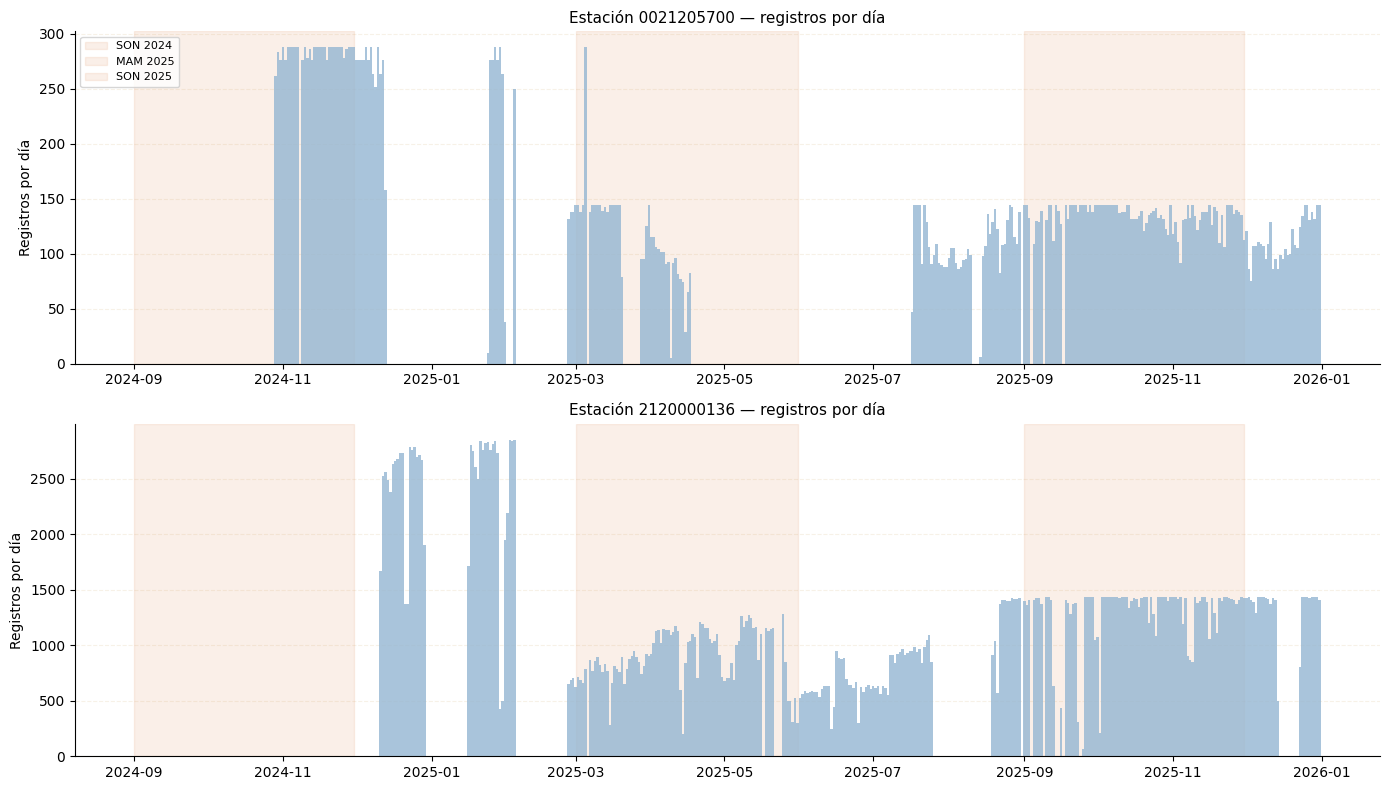

In [ ]:
# Zoom en estaciones 0021205700 y 2120000136
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Definir temporadas MAM y SON para 2024 y 2025
temporadas = [
    (pd.Timestamp('2024-09-01'), pd.Timestamp('2024-11-30'), 'SON 2024'),
    (pd.Timestamp('2025-03-01'), pd.Timestamp('2025-05-31'), 'MAM 2025'),
    (pd.Timestamp('2025-09-01'), pd.Timestamp('2025-11-30'), 'SON 2025'),
]

for ax, cod in zip(axes, ['0021205700', '2120000136']):
    df_est = pd.read_csv(f'..\\..\\data\\rainfall_subhourly\\{cod}.csv')
    df_est['fechaobservacion'] = pd.to_datetime(df_est['fechaobservacion'])
    df_est = df_est.sort_values('fechaobservacion')
    
    df_diario = df_est.groupby(df_est['fechaobservacion'].dt.date).size().reset_index()
    df_diario.columns = ['fecha', 'n_registros']
    df_diario['fecha'] = pd.to_datetime(df_diario['fecha'])
    
    # Sombrear temporadas
    for ini, fin, label in temporadas:
        ax.axvspan(ini, fin, alpha=0.12, color='#DD8047', 
                   label=label if cod == '0021205700' else '')
    
    ax.bar(df_diario['fecha'], df_diario['n_registros'],
           color='#94B6D2', alpha=0.8, width=1)
    ax.set_title(f'Estación {cod} — registros por día', fontsize=11)
    ax.set_ylabel('Registros por día')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
    ax.set_axisbelow(True)

axes[0].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

Según los resultados de esta sección, se identifican **4 estaciones** que deben ser excluídas del dataset final:

| Estación | Motivo de exclusión |
|----------|-------------------|
| `0021206990` | 10 días de datos (268 registros), sin representatividad estacional |
| `2120000104` | 2 meses de datos (oct-dic 2025), fuera del período de entrenamiento |
| `0021206980` | 7 meses con baja densidad de registros (31,417 registros) |
| `0021205700` | Gaps severos y sistemáticos (densidad real 64.1%) |

El dataset final de ground truth queda compuesto por **66 estaciones**.

In [27]:
# Lista final de estaciones excluidas
excluir = ['0021206990', '2120000104', '0021206980', '0021205700']

# Estaciones seleccionadas
estaciones_seleccionadas = df_resumen[
    ~df_resumen['estacion'].isin(excluir)
].copy()

print(f"Estaciones seleccionadas: {len(estaciones_seleccionadas)}")
print(f"Estaciones excluidas: {len(excluir)}")

# Guardar lista de estaciones seleccionadas
estaciones_seleccionadas[['estacion', 'duracion_meses', 'n_registros', 'fecha_min', 'fecha_max']].to_csv(
    'estaciones_ground_truth.csv', index=False
)
print("Guardado: estaciones_ground_truth.csv")

Estaciones seleccionadas: 66
Estaciones excluidas: 4
Guardado: estaciones_ground_truth.csv


## 3. Control de calidad: homogeneidad de las 66 estaciones seleccionadas

En esta tercera sección se atenderá a la pregunta de si dentro de esas 66 estaciones hay suficiente cobertura y densidad, o si por el contrario hay saltos artificiales, cambios de instrumento, o inconsistencias de precisión que no se relacionan con densidad de transmisión sino con la calidad del dato mismo.

Este chequeo sigue el protocolo de control de calidad descrito en Klein Tank, Zwiers & Zhang (2009), adaptado a la escala de este trabajo, cubriendo tres frentes:

1. **Metadatos**: cambios de instrumento o reubicación reportados en el catálogo IDEAM.
2. **Precisión decimal**: resolución real de los pluviómetros, necesaria para validar el umbral de 0.1 mm/h usado para definir "hora húmeda" (Ban et al., 2015; Schär et al., 2016).
3. **Inspección visual**: saltos de nivel, tramos sospechosamente planos, o anomalías dentro de las series ya seleccionadas.

#### 3.1 Preprocesamiento de los datos

Con el objeto de faculitar los análisis posteriores se hace...

In [31]:
from math import gcd
from functools import reduce

import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx

from scipy.spatial import cKDTree
from scipy.cluster.hierarchy import linkage, fcluster

In [3]:
# Lista de las 66 estaciones ya seleccionadas según la sección 2 de ground_truth_labels.ipynb
estaciones_gt = pd.read_csv('estaciones_ground_truth.csv', dtype={'estacion': str})
codigos_gt = estaciones_gt['estacion'].tolist()
print(f"Estaciones a verificar: {len(codigos_gt)}")

Estaciones a verificar: 66


##### 3.1.1 Estadísticos

(((Pendiente especificación)))

In [20]:
# Funciones para crear tabla resumen de control de calidad por estación
BANDAS = {
    'MAM_24': ('2024-03-01', '2024-06-01'),
    'SON_24': ('2024-09-01', '2024-12-01'),
    'MAM_25': ('2025-03-01', '2025-06-01'),
    'SON_25': ('2025-09-01', '2025-12-01'),
}


def cargar_datos_estacion(codigo, ruta_base=RUTA_BASE):
    """Carga el CSV crudo (registros sub-horarios) de una estación."""
    ruta = os.path.join(ruta_base, f'{codigo}.csv')
    df = pd.read_csv(ruta)
    df['fechaobservacion'] = pd.to_datetime(df['fechaobservacion'])
    return df


def agregar_precip_diaria(df):
    """Agrega registros sub-horarios a precipitación diaria (mm/día)."""
    precip_diaria = df.groupby(df['fechaobservacion'].dt.date)['valorobservado'].sum()
    precip_diaria.index = pd.to_datetime(precip_diaria.index)
    return precip_diaria


def stats_temporada(serie_diaria, ini, fin):
    """% de días con dato, descriptivos de precipitación y fecha/valor del máximo, dentro de una ventana."""
    rango = pd.date_range(ini, fin, freq='D', inclusive='left')
    ventana = serie_diaria.reindex(rango)
    desc = ventana.describe()
    if ventana.notna().any():
        fecha_max = ventana.idxmax()
        max_precip = ventana.max()
    else:
        fecha_max = pd.NaT
        max_precip = np.nan
    return {
        'pct_dias_con_dato': ventana.notna().mean(),
        'prec_media': desc.get('mean', np.nan),
        'prec_max': desc.get('max', np.nan),
        'prec_25': desc.get('25%', np.nan),
        'prec_50': desc.get('50%', np.nan),
        'prec_75': desc.get('75%', np.nan),
        'fecha_max_precip': fecha_max,
        'max_precip': max_precip,
    }


def cadencia_media_min(df, ini, fin):
    """Intervalo promedio (minutos) entre registros consecutivos, dentro de una ventana."""
    ventana = df[(df['fechaobservacion'] >= ini) & (df['fechaobservacion'] < fin)]
    deltas = ventana['fechaobservacion'].sort_values().diff().dt.total_seconds() / 60
    deltas = deltas.dropna()
    return deltas.mean() if len(deltas) > 0 else np.nan

In [25]:
# Tabla resumen de control de calidad por estación

# --- Coordenadas (+ altitud/tecnología si existen en el catálogo) ---
coords = df_catalogo_gt[['codigo', 'nombre', 'latitud', 'longitud']].copy()
coords['latitud'] = coords['latitud'].astype(float)
coords['longitud'] = coords['longitud'].astype(float)

columnas_extra_catalogo = [c for c in ['altitud', 'tecnologia'] if c in df_catalogo_gt.columns]
if columnas_extra_catalogo:
    coords = coords.merge(df_catalogo_gt[['codigo'] + columnas_extra_catalogo], on='codigo', how='left')

# --- Loop principal por estación ---
filas = []
series_diarias = {}

for codigo in coords['codigo']:
    try:
        df_estacion = cargar_datos_estacion(codigo)
    except FileNotFoundError:
        continue

    serie = agregar_precip_diaria(df_estacion)
    series_diarias[codigo] = serie

    fila = {'codigo': codigo}
    for nombre, (ini, fin) in BANDAS.items():
        s = stats_temporada(serie, ini, fin)
        fila[f'{nombre}_mean_dias_con_dato'] = s['pct_dias_con_dato']
        fila[f'{nombre}_prec_media'] = s['prec_media']
        fila[f'{nombre}_prec_max'] = s['prec_max']
        fila[f'{nombre}_prec_25'] = s['prec_25']
        fila[f'{nombre}_prec_50'] = s['prec_50']
        fila[f'{nombre}_prec_75'] = s['prec_75']
        fila[f'{nombre}_prec_max'] = s['prec_max']
        fila[f'{nombre}_fecha_max_precip'] = s['fecha_max_precip']
        fila[f'{nombre}_max_precip'] = s['max_precip']
        fila[f'{nombre}_cadencia_media'] = cadencia_media_min(df_estacion, ini, fin)

    valores = np.sort(serie.dropna().values)[::-1]
    if len(valores) > 1:
        fila['ratio_max_segundo_max'] = valores[0] / valores[1] if valores[1] > 0 else np.nan
        fila['fecha_max_global'] = serie.idxmax()
        fila['precip_max_global'] = serie.max()
    else:
        fila['ratio_max_segundo_max'] = np.nan
        fila['fecha_max_global'] = pd.NaT
        fila['precip_max_global'] = np.nan

    filas.append(fila)

df_temporadas = pd.DataFrame(filas).merge(coords, on='codigo', how='left')

# --- Orden final de columnas ---
columnas_orden = ['codigo', 'nombre', 'longitud', 'latitud'] + columnas_extra_catalogo
columnas_orden += [f'{n}_mean_dias_con_dato' for n in BANDAS]
for n in BANDAS:
    columnas_orden += [f'{n}_prec_media', f'{n}_prec_25', f'{n}_prec_50', f'{n}_prec_75',
                        f'{n}_prec_max', f'{n}_fecha_max_precip', f'{n}_max_precip']
columnas_orden += [f'{n}_cadencia_media' for n in BANDAS]
columnas_orden += ['ratio_max_segundo_max', 'fecha_max_global', 'precip_max_global']

df_temporadas = df_temporadas[columnas_orden]

columnas_cadencia = [f'{n}_cadencia_media' for n in BANDAS]
columnas_numericas = df_temporadas.select_dtypes(include='number').columns
columnas_redondeo_3 = [c for c in columnas_numericas if c not in columnas_cadencia]

df_temporadas[columnas_redondeo_3] = df_temporadas[columnas_redondeo_3].round(3)
df_temporadas[columnas_cadencia] = df_temporadas[columnas_cadencia].round(1)

df_temporadas.to_csv('resumen_qc_estaciones.csv', index=False)
df_temporadas.head(5)

,codigo,nombre,longitud,latitud,altitud,tecnologia,MAM_24_mean_dias_con_dato,SON_24_mean_dias_con_dato,MAM_25_mean_dias_con_dato,SON_25_mean_dias_con_dato,...,SON_25_prec_max,SON_25_fecha_max_precip,SON_25_max_precip,MAM_24_cadencia_media,SON_24_cadencia_media,MAM_25_cadencia_media,SON_25_cadencia_media,ratio_max_segundo_max,fecha_max_global,precip_max_global
0,2120000122,COLEGIO INEM FRANCISCO DE PAULA SANTANDER (IED...,-74.155,4.625,2557,Automática con Telemetría,0.935,0.835,0.946,0.945,...,27.0,2025-10-13,27.0,5.2,1.2,1.5,1.2,1.345,2024-11-02,44.4
1,2120000169,COLEGIO LA BELLEZA (IED) [2120000169],-74.092,4.531,2949,Automática con Telemetría,0.935,0.835,0.946,0.923,...,14.2,2025-11-21,14.2,5.7,1.3,1.7,1.2,1.438,2024-11-10,39.4
2,2120000101,ALTOS DE LA ESTANCIA [2120000101],-74.178,4.581,2960,Automática con Telemetría,0.935,0.857,0.946,0.934,...,14.1,2025-10-23,14.1,6.4,1.4,2.9,1.8,3.324,2024-11-22,67.8
3,2120000173,COLEGIO CARLO FEDERICI (IED) [2120000173],-74.159,4.672,2577,Automática con Telemetría,0.935,0.835,0.946,0.945,...,24.8,2025-10-13,24.8,5.3,1.2,1.5,1.2,1.094,2024-10-18,28.0
4,2120000120,COLEGIO GUSTAVO MORALES [2120000120],-74.064,4.717,2553,Automática con Telemetría,0.935,0.802,0.946,0.934,...,65.7,2025-10-16,65.7,5.4,1.2,1.5,1.2,1.447,2025-10-16,65.7


##### 3.1.2 Clusters

(((Pendiente especificación)))

**Método:** se agruparon las 66 estaciones en vecindarios geográficos mediante clustering jerárquico (enlace completo) sobre sus coordenadas lat/lon, con un umbral de 20 km — dos estaciones solo caen en el mismo grupo si *todas* las distancias entre los miembros del grupo están dentro de ese radio, evitando el efecto de encadenamiento de un enlace simple. 

7 clusters geográficos con radio de 20 km
cluster_geografico
1     2
2     1
3    10
4     1
5    14
6    23
7    15
Name: count, dtype: int64


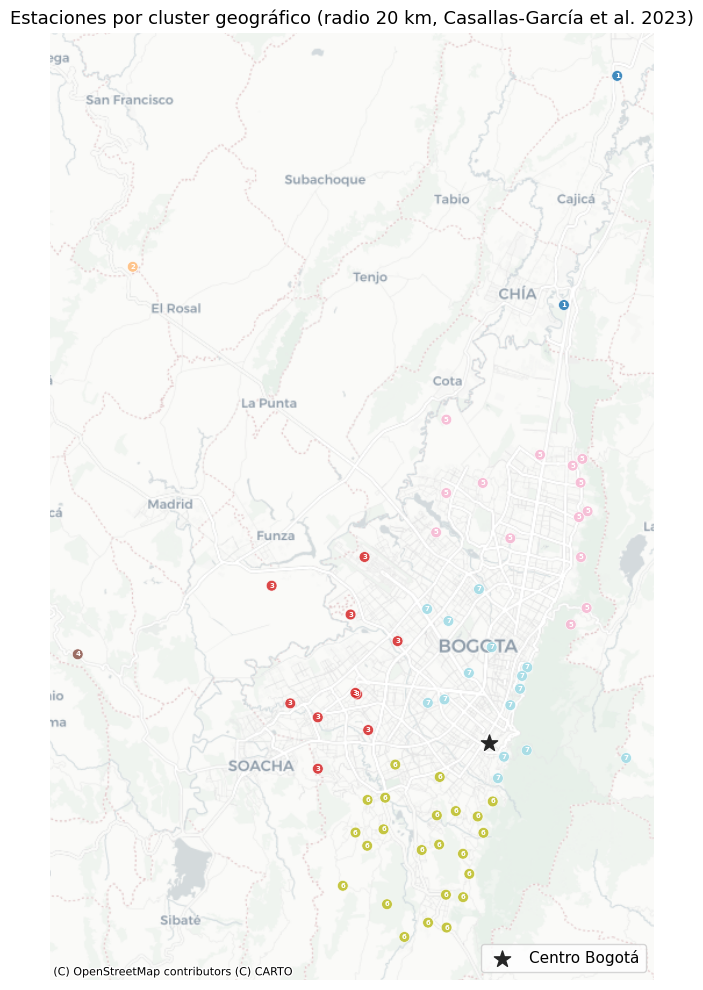

In [65]:
umbral_km = 20  # Casallas-García et al. (2023) trabaja con clusters de 16km — resolución de detección de convección profunda
umbral_deg = umbral_km / 111

coords_arr_cluster = coords[['latitud', 'longitud']].values
Z = linkage(coords_arr_cluster, method='complete')
coords = coords.copy()
coords['cluster_geografico'] = fcluster(Z, t=umbral_deg, criterion='distance')

n_clusters = coords['cluster_geografico'].nunique()
print(f"{n_clusters} clusters geográficos con radio de {umbral_km} km")
print(coords['cluster_geografico'].value_counts().sort_index())

# --- Paleta fija de colores por cluster, para reusar en todos los gráficos que sigan ---
clusters_unicos = sorted(coords['cluster_geografico'].dropna().unique())
cmap = plt.cm.tab20
colores_cluster = {c: cmap(i / max(len(clusters_unicos) - 1, 1)) for i, c in enumerate(clusters_unicos)}

# --- Mapa ---
gdf_estaciones = gpd.GeoDataFrame(
    coords,
    geometry=[Point(xy) for xy in zip(coords['longitud'], coords['latitud'])],
    crs='EPSG:4326'
).to_crs(epsg=3857)

centro = gpd.GeoDataFrame(geometry=[Point(-74.077, 4.596)], crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_estaciones['color_cluster'] = gdf_estaciones['cluster_geografico'].map(colores_cluster)
gdf_estaciones.plot(ax=ax, color=gdf_estaciones['color_cluster'],
                     markersize=60, alpha=0.85, zorder=3, edgecolor='white', linewidth=0.5)
centro.plot(ax=ax, color='#262626', markersize=150, marker='*', zorder=4, label='Centro Bogotá')

for _, fila in coords.iterrows():
    punto = gpd.GeoSeries([Point(fila['longitud'], fila['latitud'])], crs='EPSG:4326').to_crs(epsg=3857)
    ax.annotate(str(fila['cluster_geografico']), (punto.x.iloc[0], punto.y.iloc[0]),
                fontsize=5, ha='center', va='center', color='white', fontweight='bold')

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)
ax.legend(loc='lower right', fontsize=11)
ax.set_title(f'Estaciones por cluster geográfico (radio {umbral_km} km, Casallas-García et al. 2023)', fontsize=13)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('img-mapa_clusters_geograficos.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Sumar la columna a df_temporadas ---
df_temporadas = df_temporadas.merge(coords[['codigo', 'cluster_geografico']], on='codigo', how='left')

In [51]:
def p95_estacion(codigo):
    return series_diarias[codigo].quantile(0.95) if codigo in series_diarias else np.nan

df_temporadas['p95_propia'] = df_temporadas['codigo'].apply(p95_estacion)

p95_cluster_prom = {}
for cluster_id, grupo in df_temporadas.groupby('cluster_geografico'):
    codigos_cluster = grupo['codigo'].tolist()
    for codigo in codigos_cluster:
        resto_cluster = [c for c in codigos_cluster if c != codigo]
        if len(resto_cluster) == 0:
            p95_cluster_prom[codigo] = np.nan  # única estación de su cluster — sin vecinas para comparar
        else:
            p95_cluster_prom[codigo] = np.mean([p95_estacion(c) for c in resto_cluster])

df_temporadas['p95_cluster_prom'] = df_temporadas['codigo'].map(p95_cluster_prom)
df_temporadas['ratio_p95_cluster'] = df_temporadas['p95_propia'] / df_temporadas['p95_cluster_prom']

df_temporadas[['p95_propia', 'p95_cluster_prom', 'ratio_p95_cluster']] = df_temporadas[
    ['p95_propia', 'p95_cluster_prom', 'ratio_p95_cluster']
].round(2)

# Cuántas estaciones quedan sin comparación posible (únicas en su cluster)
sin_comparacion = df_temporadas['p95_cluster_prom'].isna().sum()
print(f"{sin_comparacion} estación(es) son la única de su cluster geográfico — ratio_p95_cluster queda como NaN para ellas")

df_temporadas.to_csv('resumen_qc_estaciones.csv', index=False)
df_temporadas.sort_values('ratio_p95_cluster', ascending=False).head(10)[
    ['codigo', 'nombre', 'cluster_geografico', 'p95_propia', 'p95_cluster_prom', 'ratio_p95_cluster']
]

2 estación(es) son la única de su cluster geográfico — ratio_p95_cluster queda como NaN para ellas


,codigo,nombre,cluster_geografico,p95_propia,p95_cluster_prom,ratio_p95_cluster
34,2120500204,IDEAM PUENTE ARANDA [2120500204],7,44.44,12.99,3.42
50,0021205791,EL DORADO CATAM [21205791],3,32.42,9.96,3.25
54,0021206600,NUEVA GENERACION [21206600],5,24.49,11.93,2.05
15,2120000119,COLEGIO ALEMANIA UNIFICADA [2120000119],6,12.36,8.48,1.46
19,2120000133,COLEGIO EL MANANTIAL [2120000133],6,11.90,8.50,1.40
31,2120000134,COLEGIO LOS ALPES SEDE A [2120000134],6,11.86,8.50,1.39
57,0021206560,INEM KENNEDY [21206560],3,16.10,11.78,1.37
62,0021205710,JARDIN BOTANICO [21205710],7,19.92,14.74,1.35
60,0021202190,JUAN REY - AUT [21202190],6,10.74,8.55,1.26
55,0021205910,LA COSECHA [21205910],1,19.65,15.90,1.24


### 3.1 Metadatos: catálogo de estaciones IDEAM

Se consulta el catálogo nacional de estaciones (`hp9r-jxuu`) para las 66 estaciones seleccionadas, revisando los campos de tecnología del instrumento y estado operativo.

In [4]:
# Consultar el catálogo nacional de estaciones IDEAM (hp9r-jxuu)
URL_CATALOGO = "https://www.datos.gov.co/resource/hp9r-jxuu.json"

catalogo_rows = []
limite = 1000
offset = 0
while True:
    params = {"$limit": limite, "$offset": offset}
    resp = requests.get(URL_CATALOGO, params=params)
    resp.raise_for_status()
    batch = resp.json()
    if not batch:
        break
    catalogo_rows.extend(batch)
    offset += limite

df_catalogo = pd.DataFrame(catalogo_rows)
print(f"Total de estaciones en el catálogo nacional: {len(df_catalogo)}")
print(f"Columnas disponibles: {df_catalogo.columns.tolist()}")

Total de estaciones en el catálogo nacional: 9691
Columnas disponibles: ['codigo', 'nombre', 'categoria', 'tecnologia', 'estado', 'departamento', 'municipio', 'ubicaci_n', 'altitud', 'longitud', 'latitud', 'fecha_instalacion', 'area_operativa', 'area_hidrografica', 'zona_hidrografica', 'subzona_hidrografica', 'entidad', 'corriente', 'fecha_suspension']


In [5]:
# Filtrado sobre las 66 estaciones
col_codigo = 'codigo'

df_catalogo_gt = df_catalogo[df_catalogo[col_codigo].isin(codigos_gt)].copy()
print(f"Estaciones encontradas en el catálogo: {len(df_catalogo_gt)} de {len(codigos_gt)}")

faltantes = set(codigos_gt) - set(df_catalogo_gt[col_codigo])
if faltantes:
    print(f"\n⚠️ No encontradas en el catálogo (revisar código manualmente): {sorted(faltantes)}")

# Columnas relevantes, incluyendo fechas de instalación y suspensión —
# estas sí permiten detectar cambios dentro del período de estudio, a diferencia
# de 'tecnologia'/'estado', que solo reflejan el estado actual
cols_relevantes = [c for c in ['codigo', 'nombre', 'categoria', 'tecnologia', 'estado',
                                 'fecha_instalacion', 'fecha_suspension',
                                 'departamento', 'municipio'] if c in df_catalogo_gt.columns]
df_catalogo_gt[cols_relevantes].head(5)

Estaciones encontradas en el catálogo: 66 de 66


,codigo,nombre,categoria,tecnologia,estado,fecha_instalacion,fecha_suspension,departamento,municipio
42,2120000122,COLEGIO INEM FRANCISCO DE PAULA SANTANDER (IED...,Pluviométrica,Automática con Telemetría,Activa,01/11/2016,NaN,Bogotá,"Bogotá, D.C"
49,2120000169,COLEGIO LA BELLEZA (IED) [2120000169],Pluviométrica,Automática con Telemetría,Activa,01/09/2019,NaN,Bogotá,"Bogotá, D.C"
146,2120000101,ALTOS DE LA ESTANCIA [2120000101],Pluviométrica,Automática con Telemetría,Activa,19/06/2018,NaN,Bogotá,"Bogotá, D.C"
158,2120000173,COLEGIO CARLO FEDERICI (IED) [2120000173],Pluviométrica,Automática con Telemetría,Activa,01/12/2019,NaN,Bogotá,"Bogotá, D.C"
213,2120000120,COLEGIO GUSTAVO MORALES [2120000120],Pluviométrica,Automática con Telemetría,Activa,01/11/2016,NaN,Bogotá,"Bogotá, D.C"


El catálogo trae dos tipos de campo distintos.
- `tecnologia` y `estado` son un snapshot del estado actual, no un historial, y por diseño no permiten detectar si una estación cambió de tecnología o estado *durante* 2024-2025.
- `fecha_instalacion` y `fecha_suspension` sí son campos de fecha con potencial para eso, pero como se ve más abajo, ninguno de los dos aporta una señal para las 66 estaciones seleccionadas: ninguna fecha de instalación cae dentro del período, y `fecha_suspension` no está diligenciada ni siquiera para las estaciones que sí cambiaron de estado. El catálogo, entonces, no permite confirmar cambios de instrumento o reubicación dentro del período, pero tampoco permite descartarlos con certeza para las estaciones marcadas más abajo. Esa verificación recae en la inspección visual de la Sección 3.2.

In [6]:
# Distribución de tecnología y estado
if 'tecnologia' in df_catalogo_gt.columns:
    print("Distribución de tecnología entre las 66 estaciones:")
    print(df_catalogo_gt['tecnologia'].value_counts().to_frame(name='n_estaciones'))

if 'estado' in df_catalogo_gt.columns:
    print("\nDistribución de estado operativo:")
    print(df_catalogo_gt['estado'].value_counts().to_frame(name='n_estaciones'))
    no_activas = df_catalogo_gt[~df_catalogo_gt['estado'].str.contains('Activ', case=False, na=False)]
    if len(no_activas) > 0:
        print(f"\n⚠️ {len(no_activas)} estación(es) sin estado activo — revisar manualmente:")
        cols_estado = [c for c in ['codigo', 'nombre', 'categoria', 'tecnologia', 'estado',
                                     'fecha_instalacion', 'fecha_suspension'] if c in df_catalogo_gt.columns]
        display(no_activas[cols_estado])
    else:
        print("\nTodas las estaciones aparecen activas en el catálogo.")

Distribución de tecnología entre las 66 estaciones:
                                         n_estaciones
tecnologia                                           
Automática con Telemetría                          58
Automática con Telemetría, Convencional             8

Distribución de estado operativo:
                  n_estaciones
estado                        
Activa                      64
Suspendida                   1
En Mantenimiento             1

⚠️ 2 estación(es) sin estado activo — revisar manualmente:


,codigo,nombre,categoria,tecnologia,estado,fecha_instalacion,fecha_suspension
1318,2120000136,COL. LOS PINOS SEDE A [2120000136],Pluviométrica,Automática con Telemetría,Suspendida,01/10/2018,NaN
9471,0035025060,LA BOLSA [35025060],Climatológica Principal,"Automática con Telemetría, Convencional",En Mantenimiento,15/05/1987,NaN


Ocho estaciones tienen registrado tanto instrumento automático como convencional en el mismo sitio, no se toma como hallazgo por sí solo, ya que el campo describe el inventario de instrumentos presentes, no un cambio ocurrido dentro del período.

Dos estaciones no aparecen activas: `2120000136` (Suspendida, instalada en 2018) y `0035025060` (En Mantenimiento, instalada en 1987). Llama la atención que `2120000136`, estando suspendida, no tenga fecha de suspensión registrada, si el catálogo refleja un cambio de estado real, se esperaría que ese campo estuviera diligenciado. Sin esa fecha, no se puede establecer si la suspensión ocurrió dentro o después del período de estudio. Ambas estaciones quedan marcadas para revisión puntual en la inspección visual general de la Sección 3.2, con atención particular a los últimos meses de 2025.

In [7]:
# Verificación de fechas: instalación y suspensión dentro del período de estudio (2024-2025)
# Este chequeo sí puede detectar cambios dentro del período, a diferencia de 'tecnologia'/'estado'
df_catalogo_gt['fecha_instalacion'] = pd.to_datetime(df_catalogo_gt['fecha_instalacion'], errors='coerce')
df_catalogo_gt['fecha_suspension'] = pd.to_datetime(df_catalogo_gt['fecha_suspension'], errors='coerce')

inicio_periodo = pd.Timestamp('2024-01-01')
fin_periodo = pd.Timestamp('2025-12-31')
cols_fechas = ['codigo', 'nombre', 'fecha_instalacion', 'fecha_suspension', 'estado']

# Estaciones instaladas dentro o después del inicio del período de estudio —
# señal de que el registro actual del instrumento es más reciente que el propio período,
# lo que podría indicar una reinstalación o reubicación no documentada de otra forma
instaladas_en_periodo = df_catalogo_gt[df_catalogo_gt['fecha_instalacion'] >= inicio_periodo]
if len(instaladas_en_periodo) > 0:
    print(f"⚠️ {len(instaladas_en_periodo)} estación(es) con fecha de instalación dentro o después del período de estudio:")
    display(instaladas_en_periodo[cols_fechas])
else:
    print("Ninguna estación seleccionada tiene fecha de instalación dentro del período 2024-2025.")

print()

# Estaciones con fecha de suspensión — verificar si cae dentro o después del período
con_suspension = df_catalogo_gt[df_catalogo_gt['fecha_suspension'].notna()]
if len(con_suspension) > 0:
    print("Estaciones con fecha de suspensión registrada:")
    display(con_suspension[cols_fechas])
    dentro_periodo = con_suspension[
        (con_suspension['fecha_suspension'] >= inicio_periodo) &
        (con_suspension['fecha_suspension'] <= fin_periodo)
    ]
    if len(dentro_periodo) > 0:
        print(f"\n🚩 {len(dentro_periodo)} estación(es) suspendida(s) DENTRO del período de estudio — revisar la serie con atención:")
        display(dentro_periodo[cols_fechas])
    else:
        print("\nNinguna suspensión registrada cae dentro del período 2024-2025 (posteriores, no afectan los datos usados).")
else:
    print("Ninguna de las 66 estaciones tiene fecha de suspensión registrada.")

Ninguna estación seleccionada tiene fecha de instalación dentro del período 2024-2025.

Ninguna de las 66 estaciones tiene fecha de suspensión registrada.


Ninguna de las 66 estaciones tiene fecha de instalación dentro de 2024-2025 — descarta la señal más directa que este catálogo podía ofrecer sobre una reinstalación o reubicación no documentada de otra forma. La fecha de suspensión no está diligenciada para ninguna estación, incluidas las dos marcadas como no activas, así que el catálogo tampoco permite confirmar ni descartar si esos cambios de estado cayeron dentro del período de estudio.

Con esto se cierra la revisión de metadatos: no aporta evidencia de cambios dentro de 2024-2025 para ninguna de las 66 estaciones, pero deja a `2120000136` y `0035025060` sin resolver, pendientes de la inspección visual directa de sus series completas. El resto de series temporales no requiere seguimiento adicional derivado de esta sección.

### 3.2 Precisión decimal de los pluviómetros

El umbral de 0.1 mm/h usado para definir "hora húmeda" (Ban et al., 2015) asume que los pluviómetros pueden, en principio, distinguir esa magnitud. Si la resolución real de un instrumento es más gruesa que 0.1 mm (por ejemplo, reporta en incrementos de 0.2 o 0.5 mm), el umbral no tiene significado operativo para esa estación — cualquier valor no-cero ya supera por diseño el piso de detección, independientemente de cuánto llovió realmente.

**Método:** para cada estación, se calcula el máximo común divisor de todos sus valores sub-horarios no-cero (escalados a enteros para evitar errores de coma flotante). Ese MCD es la resolución mínima real de incremento del instrumento — el "paso" más pequeño que el sensor es capaz de reportar.

In [17]:
# Distribución de resolución entre las estaciones
RUTA_BASE = r'..\..\data\rainfall_subhourly'

def resolucion_estacion(codigo, ruta_base=RUTA_BASE):
    """Devuelve resolución (MCD), cantidad de valores únicos no-cero, y la lista de esos valores."""
    ruta = os.path.join(ruta_base, f'{codigo}.csv')
    df = pd.read_csv(ruta)
    no_cero = df.loc[df['valorobservado'] > 0, 'valorobservado']
    if len(no_cero) == 0:
        return np.nan, 0, []
    valores_unicos = sorted(no_cero.unique())
    enteros = (no_cero * 100).round().astype(int).unique()
    resolucion = reduce(gcd, enteros) / 100
    return resolucion, len(valores_unicos), valores_unicos

resumen_resolucion = []
for codigo in df_catalogo_gt['codigo']:
    try:
        resolucion, n_unicos, valores_unicos = resolucion_estacion(codigo)
        resumen_resolucion.append({
            'codigo': codigo,
            'resolucion_mm': resolucion,
            'n_valores_unicos': n_unicos,
            'valores_unicos': valores_unicos,
        })
    except FileNotFoundError:
        resumen_resolucion.append({'codigo': codigo, 'resolucion_mm': np.nan,
                                     'n_valores_unicos': 0, 'valores_unicos': []})

df_resolucion = pd.DataFrame(resumen_resolucion)
df_resolucion['cumple_umbral_01mm'] = df_resolucion['resolucion_mm'] <= 0.1

# Sospechosas de artefacto: resolución mucho más fina que el resto de la red
# (0.1/0.2 son los valores normales — cualquier cosa por debajo de eso amerita mirar los valores mismos)
umbral_sospecha_artefacto = 0.05
df_resolucion['posible_artefacto'] = df_resolucion['resolucion_mm'] < umbral_sospecha_artefacto

print("Distribución de resolución real entre las 66 estaciones:")
display(df_resolucion['resolucion_mm'].value_counts().sort_index().to_frame(name='n_estaciones'))

casos_a_revisar = df_resolucion[
    (~df_resolucion['cumple_umbral_01mm']) | (df_resolucion['posible_artefacto'])
].copy()

if len(casos_a_revisar) > 0:
    print(f"\n⚠️ {len(casos_a_revisar)} estación(es) a revisar — resolución gruesa (>0.1mm) o sospechosa de artefacto (<0.05mm):\n")
    for _, fila in casos_a_revisar.iterrows():
        motivo = []
        if not fila['cumple_umbral_01mm']:
            motivo.append('resolución gruesa')
        if fila['posible_artefacto']:
            motivo.append('posible artefacto (revisar valores)')
        print(f"  {fila['codigo']} — resolución MCD: {fila['resolucion_mm']} mm | motivo: {', '.join(motivo)}")
        print(f"    {fila['n_valores_unicos']} valores únicos no-cero: {fila['valores_unicos'][:15]}"
              f"{' ...' if fila['n_valores_unicos'] > 15 else ''}")
        print()
else:
    print("\nTodas las estaciones tienen resolución razonable (0.05-0.1 mm) y sin señales de artefacto.")

df_resolucion.drop(columns='valores_unicos').to_csv('resolucion_decimal_estaciones.csv', index=False)

Distribución de resolución real entre las 66 estaciones:


,n_estaciones
resolucion_mm,
0.01,1
0.10,63
0.20,2



⚠️ 3 estación(es) a revisar — resolución gruesa (>0.1mm) o sospechosa de artefacto (<0.05mm):

  2120500135 — resolución MCD: 0.2 mm | motivo: resolución gruesa
    36 valores únicos no-cero: [np.float64(0.2), np.float64(0.4), np.float64(0.6), np.float64(0.8), np.float64(1.0), np.float64(1.2), np.float64(1.4), np.float64(1.6), np.float64(1.8), np.float64(2.0), np.float64(2.2), np.float64(2.4), np.float64(2.6), np.float64(2.8), np.float64(3.0)] ...

  0021205791 — resolución MCD: 0.01 mm | motivo: posible artefacto (revisar valores)
    1131 valores únicos no-cero: [np.float64(0.001), np.float64(0.002), np.float64(0.003), np.float64(0.004), np.float64(0.005), np.float64(0.006), np.float64(0.007), np.float64(0.008), np.float64(0.009), np.float64(0.01), np.float64(0.011), np.float64(0.012), np.float64(0.013), np.float64(0.014), np.float64(0.015)] ...

  0021205910 — resolución MCD: 0.2 mm | motivo: resolución gruesa
    39 valores únicos no-cero: [np.float64(0.2), np.float64(0.4), np.flo

De las 66 estaciones, 63 reportan una resolución de 0.1 mm, igual al umbral operativo. Tres quedan fuera de ese patrón:

**`2120500135` y `0021205910` — resolución de 0.2 mm.** Los valores no-cero de ambas son múltiplos limpios de 0.2 (0.2, 0.4, 0.6, 0.8...), sin ruido ni valores sueltos rompiendo el patrón — es la resolución real del instrumento, no un artefacto de cálculo. Para estas dos, el umbral de 0.1 mm/h queda por debajo de lo que el sensor puede distinguir: cualquier lectura no-cero ya representa el doble del piso de detección asumido. Se revisan en detalle a continuación.

**`0021205791` — resolución nominal de 0.01 mm, pero con 1,131 valores únicos distintos** (0.001, 0.002, 0.003 mm...), prácticamente cada incremento posible de milésimas. Esto no corresponde a la resolución de un pluviómetro de balancín real — ningún instrumento de este tipo reporta a esa escala — y sugiere una señal de fondo casi continua más que lluvia discretizada en "tips" del instrumento. También amerita revisión en detalle.

#### 3.2.1 `2120500135` y `0021205910` — resolución gruesa, sin evidencia de contaminación

Ambas estaciones son vecinas geográficas reales (mismo `cluster_geografico`, radio 20 km), y comparten un perfil casi idéntico: misma cobertura por temporada, cadencia prácticamente igual en las tres temporadas con datos, aunque notablemente más lenta que la referencia general de la red (~2 min). `0021205910` está catalogada como "Automática con Telemetría, Convencional"; `2120500135` no lleva esa etiqueta, pero el perfil compartido sugiere que pertenece al mismo tipo de instrumento o generación de instalación, con el campo de tecnología posiblemente incompleto en el catálogo para este caso puntual.

Es de notar que ninguna de las dos muestra señal de sobrerreporte: `ratio_p95_cluster` de 0.81 y 1.24 (cercano a 1, sin desviación relevante) y `ratio_max_segundo_max` de 1.26 y 1.32 (sin picos aislados sospechosos). 
- *Nota metodológica*: al ser las únicas dos estaciones de su cluster, cada `ratio_p95_cluster` se compara contra una sola estación, no contra un promedio — una comparación de baja potencia estadística, aunque en este caso el resultado (ambas cercanas a 1) no cambia con esa limitación.

**Tratamiento:** se conservan en el dataset final, sin exclusión, bajo el Criterio #1.

#### Criterio #1, Resolución instrumental insuficiente (-limitación-)

El umbral de 0.1 mm/h usado para definir "hora húmeda" no tiene piso de detección real para estas dos estaciones, cuya resolución de reporte es de 0.2 mm — cualquier lectura no-cero ya representa el doble de ese umbral. Se documenta como limitación explícita al reportar el umbral operativo final, no como motivo de exclusión.

In [52]:
perfil_coarse = df_temporadas[df_temporadas['codigo'].isin(['2120500135', '0021205910'])][
    ['codigo', 'nombre', 'cluster_geografico', 'tecnologia', 'altitud', 
     'MAM_24_mean_dias_con_dato', 'SON_24_mean_dias_con_dato',
     'MAM_25_mean_dias_con_dato', 'SON_25_mean_dias_con_dato',
     'ratio_p95_cluster', 'ratio_max_segundo_max',
     'MAM_24_cadencia_media', 'SON_24_cadencia_media',
     'MAM_25_cadencia_media', 'SON_25_cadencia_media']
]
display(perfil_coarse)

,codigo,nombre,cluster_geografico,tecnologia,altitud,MAM_24_mean_dias_con_dato,SON_24_mean_dias_con_dato,MAM_25_mean_dias_con_dato,SON_25_mean_dias_con_dato,ratio_p95_cluster,ratio_max_segundo_max,MAM_24_cadencia_media,SON_24_cadencia_media,MAM_25_cadencia_media,SON_25_cadencia_media
21,2120500135,UNIVERSIDAD DE LA SABANA [2120500135],1,Automática con Telemetría,2548,0.0,0.462,0.87,0.967,0.81,1.257,NaN,12.4,11.4,10.4
55,0021205910,LA COSECHA [21205910],1,"Automática con Telemetría, Convencional",2570,0.0,0.462,0.87,0.967,1.24,1.321,NaN,12.4,11.4,10.6


#### 3.2.2 `0021205791`, El Dorado

El perfil resumen de esta estación se aparta del patrón observado en las otras dos candidatas de resolución gruesa (Sección 3.2.1), lo que amerita una revisión individual más profunda antes de decidir su tratamiento en el dataset final.

**Perfil resumen:**

| Métrica | `El Dorado` | `U. De La Sabana` | `La Cosecha` |
|---|---|---|---|
| `ratio_p95_cluster` | 3.25 | 0.81 | 1.24 |
| `ratio_max_segundo_max` | 2.63 | 1.26 | 1.32 |
| Cadencia (SON_24 → SON_25) | 5.2 → 1.7 min | ~12.4 → ~10.4 min | ~12.4 → ~10.6 min |

**Lo que distingue a esta estación:**

- **`ratio_p95_cluster` de 3.25** — más del triple del promedio de su cluster geográfico, muy por encima de las otras dos candidatas de la sección anterior, que rondan 1 (comportamiento normal frente a su entorno).
- **`ratio_max_segundo_max` de 2.63** — su día más extremo se despega también de su propio segundo lugar, algo que no se observa en las otras dos.
- **Cadencia inestable en el tiempo**, y en dirección opuesta a lo esperado: en vez de mantenerse estable como un instrumento más lento por diseño (patrón de `2120500135`/`0021205910`), pasa de 5.2 min en SON_24 a 1.7 min en MAM_25 y SON_25, terminando más rápida que el promedio de la red, no más lenta. Esto no es consistente con un instrumento simplemente más grueso o de una generación distinta; sugiere un comportamiento de reporte variable que amerita explicación aparte.

In [53]:
perfil_coarse = df_temporadas[df_temporadas['codigo'].isin(['0021205791'])][
    ['codigo', 'nombre', 'cluster_geografico', 'tecnologia', 'altitud', 
     'MAM_24_mean_dias_con_dato', 'SON_24_mean_dias_con_dato',
     'MAM_25_mean_dias_con_dato', 'SON_25_mean_dias_con_dato',
     'ratio_p95_cluster', 'ratio_max_segundo_max',
     'MAM_24_cadencia_media', 'SON_24_cadencia_media',
     'MAM_25_cadencia_media', 'SON_25_cadencia_media']
]
display(perfil_coarse)

,codigo,nombre,cluster_geografico,tecnologia,altitud,MAM_24_mean_dias_con_dato,SON_24_mean_dias_con_dato,MAM_25_mean_dias_con_dato,SON_25_mean_dias_con_dato,ratio_p95_cluster,ratio_max_segundo_max,MAM_24_cadencia_media,SON_24_cadencia_media,MAM_25_cadencia_media,SON_25_cadencia_media
50,0021205791,EL DORADO CATAM [21205791],3,Automática con Telemetría,2547,0.0,0.352,0.946,0.978,3.25,2.631,NaN,5.2,1.7,1.7


**Conclusión de análisis de precisión decimal del pluviómetro de El Dorado:** el perfil resumen por sí solo ya distingue a esta estación como cualitativamente distinta de las otras dos candidatas de resolución gruesa — no como una variante del mismo problema, sino como un caso que requiere investigación individual.

### 3.3 Inspección visual: saltos, tramos planos y anomalías

A diferencia del control de densidad ya hecho (que detecta *ausencia* de datos), aquí se busca detectar problemas dentro de los datos que sí están presentes: cambios de nivel abruptos que no correspondan a un evento de lluvia real, tramos sospechosamente constantes (posible sensor atascado), o cambios visibles en la granularidad de los valores reportados.

#### 3.3.1 Cobertura por temporada de lluvia (MAM/SON)
Se grafican las 66 series en una grilla compacta para escaneo visual rápido, agregadas a nivel diario para que el patrón sea legible a esta escala.

66 códigos reordenados geográficamente


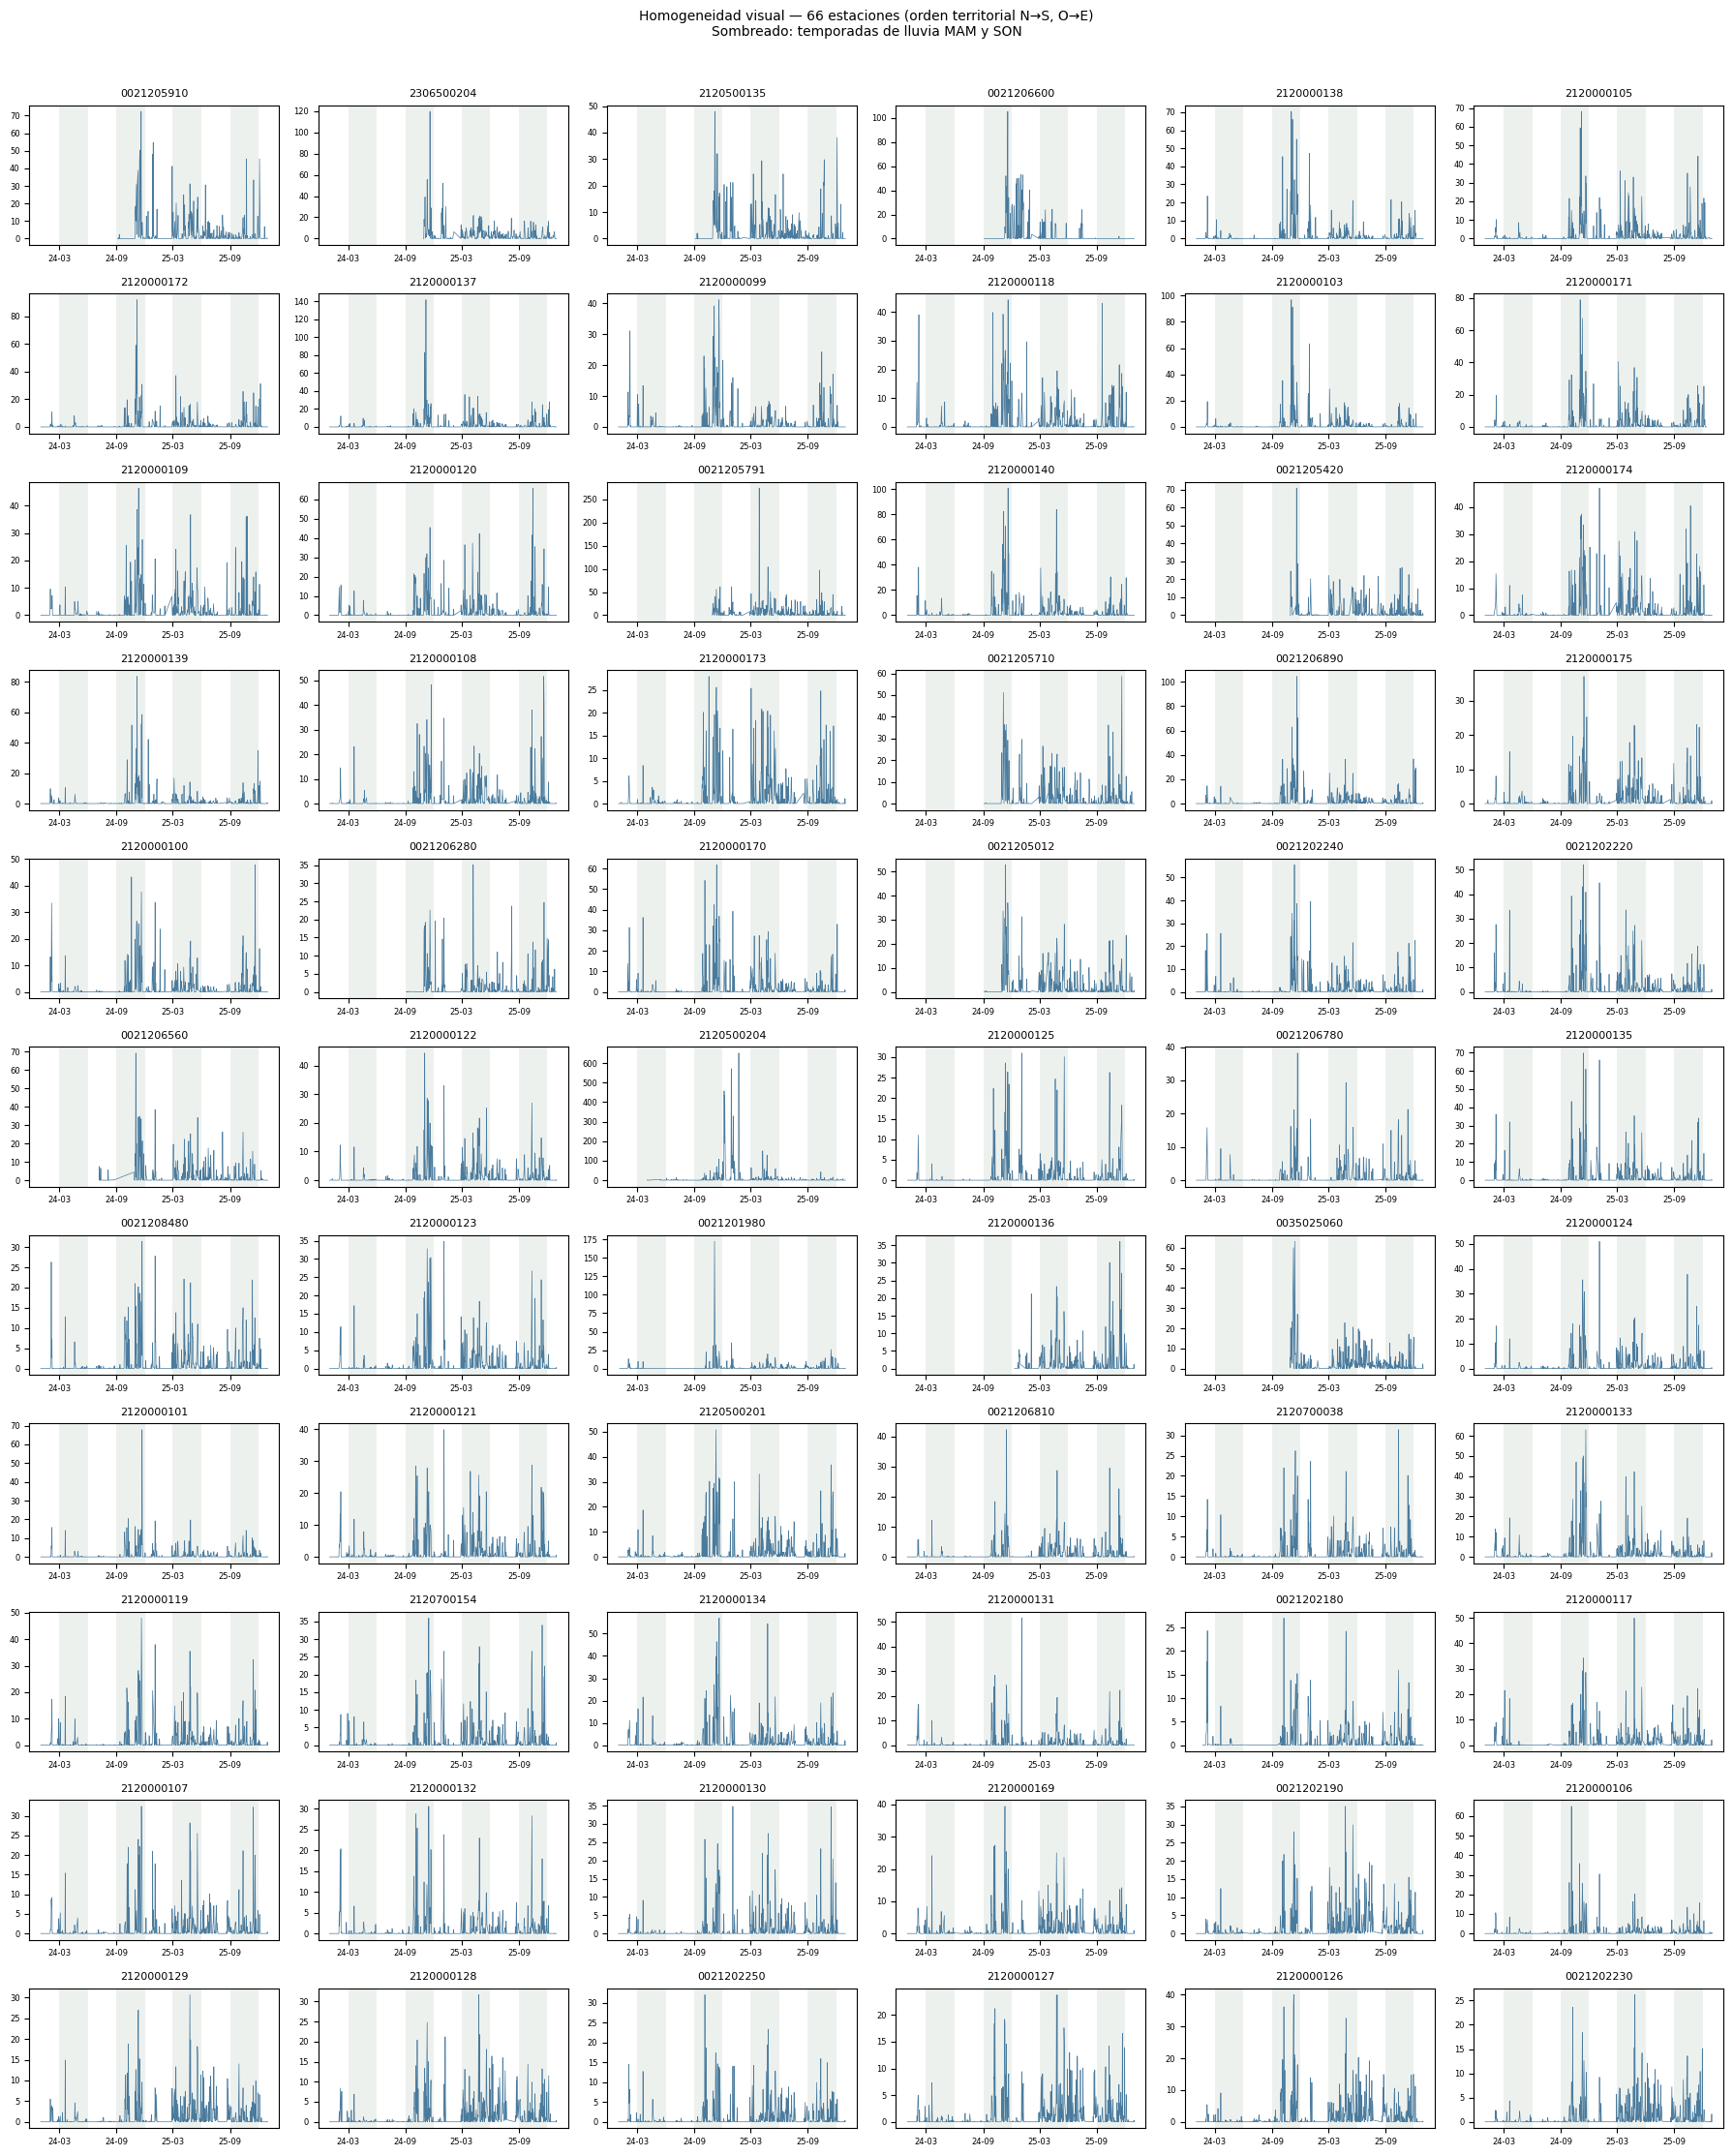

In [ ]:
# Vista de las series temporales de las estaciones candidatas, ordenadas territorialmente

def cargar_precip_diaria(codigo, ruta_base=RUTA_BASE):
    """Carga el CSV de una estación y agrega a precipitación diaria."""
    ruta = os.path.join(ruta_base, f'{codigo}.csv')
    df = pd.read_csv(ruta)
    df['fechaobservacion'] = pd.to_datetime(df['fechaobservacion'])
    precip_diaria = df.groupby(df['fechaobservacion'].dt.date)['valorobservado'].sum()
    precip_diaria.index = pd.to_datetime(precip_diaria.index)
    return precip_diaria


def sombrear_temporada_humeda(ax, anio_inicio, anio_fin, color='#9EB2A4', alpha=0.18):
    """Sombrea las temporadas de lluvia bimodales de Bogotá (MAM y SON) para cada año del rango."""
    for anio in range(anio_inicio, anio_fin + 1):
        ax.axvspan(pd.Timestamp(f'{anio}-03-01'), pd.Timestamp(f'{anio}-06-01'),
                   color=color, alpha=alpha, lw=0, zorder=0)
        ax.axvspan(pd.Timestamp(f'{anio}-09-01'), pd.Timestamp(f'{anio}-12-01'),
                   color=color, alpha=alpha, lw=0, zorder=0)


# Ordenamiento territorial: norte -> sur como criterio principal,
# oeste -> este como desempate, para que estaciones cercanas
# queden en posiciones consecutivas de la grilla
coords = df_catalogo_gt[['codigo', 'latitud', 'longitud']].copy()
coords['latitud'] = coords['latitud'].astype(float)
coords['longitud'] = coords['longitud'].astype(float)

orden_territorial = coords.sort_values(['latitud', 'longitud'], ascending=[False, True])
codigos_gt_territorial = orden_territorial['codigo'].tolist()

print(f"{len(codigos_gt_territorial)} códigos reordenados geográficamente")

n_cols = 6
n_rows = -(-len(codigos_gt_territorial) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 2 * n_rows), sharex=True)
axes = axes.flatten()

series_diarias = {}

for i, codigo in enumerate(codigos_gt_territorial):
    try:
        serie = cargar_precip_diaria(codigo)
        series_diarias[codigo] = serie
        sombrear_temporada_humeda(axes[i], 2024, 2025)
        axes[i].plot(serie.index, serie.values, lw=0.5, color='#4A7B9D', zorder=2)
        axes[i].set_title(codigo, fontsize=8)
        axes[i].tick_params(labelsize=6)
    except FileNotFoundError:
        axes[i].set_title(f"{codigo} (no encontrado)", fontsize=8, color='red')

for j in range(len(codigos_gt_territorial), len(axes)):
    axes[j].axis('off')

# Forzar etiquetas de fecha en TODOS los paneles, no solo la última fila,
# con formato yy-mm y menos ticks para que no se solapen
locator = mdates.MonthLocator(interval=6)  # un tick cada 6 meses
formatter = mdates.DateFormatter('%y-%m')

for ax in axes[:len(codigos_gt_territorial)]:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(labelbottom=True, labelsize=6)

fig.suptitle('Homogeneidad visual — 66 estaciones (orden territorial N→S, O→E)\n'
             'Sombreado: temporadas de lluvia MAM y SON', fontsize=10, y=1.01)

plt.tight_layout()
plt.savefig('img-homogeneidad_grid_66_estaciones.png', dpi=150, bbox_inches='tight')
plt.show()

El sombreado de las temporadas bimodales de Bogotá (MAM y SON) sobre la grilla territorial deja ver, a simple vista, que **MAM 2024 tiene notoriamente menos datos** que las otras tres franjas en la mayoría de los paneles, pareciendo que en general la serie suele arrancar recién hacia SON 2024. Esto es consistente con lo ya documentado sobre la reactivación tardía de la red en 2023-2024.

A continuación se cuantifica esto con precisión (por estación, no solo a simple vista) antes de sacar conclusiones sobre su impacto en el cálculo del umbral operativo.

#### 3.3.2 Trayectoria de cobertura y estabilización de la red

La trayectoria de cobertura por estación a través de las cuatro temporadas muestra dos comportamientos claramente diferenciados:

- **Mayoría estable:** la mayor parte de las 66 estaciones mantiene una cobertura alta (~0.80–0.95) de forma prácticamente constante en las cuatro ventanas, sin una tendencia marcada de mejora ni deterioro.

- **Un subgrupo con arranque bajo y recuperación progresiva:** un conjunto menor de estaciones parte de coberturas muy inferiores en MAM 2024, no de forma binaria (0% o 100%), sino en un espectro de puntos de partida (desde 0% hasta ~68%), y converge hacia el mismo rango que la mayoría hacia MAM/SON 2025. La convergencia es progresiva a través de las cuatro ventanas, no un salto abrupto entre dos de ellas.

Distinguiendo por tipo de sensor (línea sólida = automática; punteada = automática + convencional), ambos subtipos de tecnología están presentes dentro del grupo de arranque bajo, y ambos siguen una trayectoria de recuperación con la misma forma general. Esto sugiere que el fenómeno no es exclusivo de un tipo de sensor: la tecnología híbrida coincide con parte del grupo de arranque bajo, pero no lo explica por completo, ya que estaciones puramente automáticas muestran el mismo patrón.

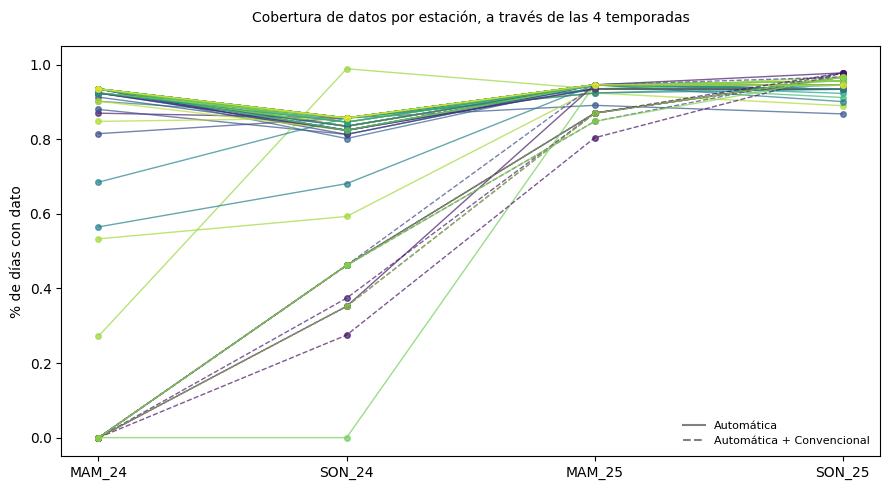

In [60]:
# Porcentaje de días con datos por estación
temporadas_orden = ['MAM_24', 'SON_24', 'MAM_25', 'SON_25']

# Orden para el degradé: por tecnología primero (así el grupo híbrido
# queda agrupado en tonos vecinos), y dentro de cada grupo por MAM_24
# (para que el degradé también siga un criterio con sentido)
orden_color = df_temporadas.sort_values(
    ['cluster_geografico', 'MAM_24_mean_dias_con_dato'], na_position='first')['codigo'].tolist()

cmap = plt.cm.viridis
colores_estacion = {
    codigo: cmap(i / (len(orden_color) - 1))
    for i, codigo in enumerate(orden_color)
}

estilos_linea = {
    'Automática con Telemetría': '-',
    'Automática con Telemetría, Convencional': '--',
}

fig, ax = plt.subplots(figsize=(9, 5))

for _, fila in df_temporadas.iterrows():
    valores = [fila[f'{t}_mean_dias_con_dato'] for t in temporadas_orden]
    ax.plot(temporadas_orden, valores,
            color=colores_estacion[fila['codigo']],
            linestyle=estilos_linea.get(fila['tecnologia'], '-'),
            marker='o', markersize=4, linewidth=1, alpha=0.7)

ax.set_ylabel('% de días con dato')
ax.set_ylim(-0.05, 1.05)
ax.set_title('Cobertura de datos por estación, a través de las 4 temporadas\n', fontsize=10)
leyenda_estilo = [
    Line2D([0], [0], color='gray', linestyle='-', label='Automática'),
    Line2D([0], [0], color='gray', linestyle='--', label='Automática + Convencional'),
]
ax.legend(handles=leyenda_estilo, loc='lower right', fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig('img-cobertura_por_estacion_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

Este resultado tiene coherencia con resultados vistos anteriormente (ver notebook `01-ground_truth_exploration.ipynb`, sección 3.2), donde era visible, considerando, la cobertura completo de la red (2018-2026), que el número de estaciones activas cae a su mínimo en 2021-2022 (12 y 10 estaciones, respectivamente), y aunque 2023 ya cuenta con el número casi final de estaciones (66, prácticamente el mismo total usado en este trabajo), su mediana de registros por estación (7,532) es la más baja de toda la serie histórica,  evidencia de que la infraestructura física ya estaba instalada, pero el reporte todavía no era confiable. Recién en 2024 la mediana sube a 189,785 y en 2025 a 353,808, consolidando el nivel de densidad que sostiene el resto de este trabajo.

La trayectoria de cobertura por temporada (imagen arriba) es, en ese sentido, la misma historia vista con más resolución: no un hallazgo nuevo y separado, sino la cola fina de esa estabilización de red, mostrando en qué momento dentro de 2024, no solo en qué año, cada estación terminó de alcanzar un nivel de reporte confiable.

#### 3.3.3 Coherencia espacial de las fechas de máximo estacional

Se busca inspeccionar visualmente cómo se comporta el pico de precipitación máxima por temporada entre las 66 estaciones, considerando únicamente las ventanas MAM y SON, y agrupando las estaciones por cercanía geográfica (clustering). El objetivo es distinguir dos escenarios distintos que una fecha de máximo compartida entre estaciones no permite diferenciar por sí
sola: una tormenta regional real que afectó a varias estaciones a la vez, o una coincidencia de fecha entre estaciones sin relación geográfica entre sí.

In [61]:
# Tabla larga de picos (una fila por estación-temporada)
temporadas_orden = ['MAM_24', 'SON_24', 'MAM_25', 'SON_25']

registros_pico = []
for _, fila in df_temporadas.iterrows():
    for temporada in temporadas_orden:
        fecha = fila[f'{temporada}_fecha_max_precip']
        valor = fila[f'{temporada}_max_precip']
        if pd.notna(fecha) and pd.notna(valor):
            registros_pico.append({
                'codigo': fila['codigo'],
                'fecha': pd.to_datetime(fecha),
                'max_precip': valor,
            })

df_picos = pd.DataFrame(registros_pico)

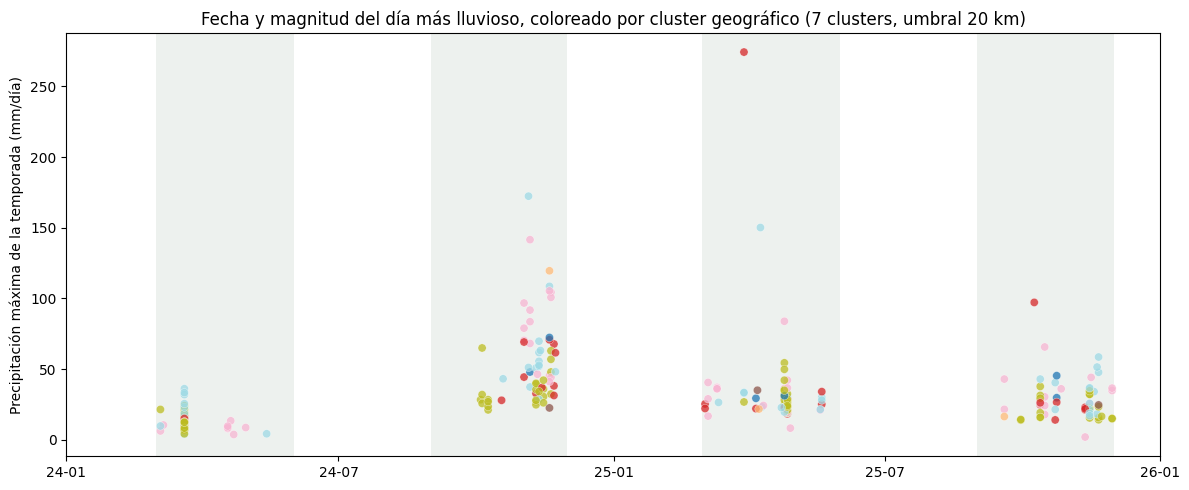

In [ ]:
# Día más lluvioso coloreado por cluster geográfico
df_picos = pd.DataFrame(registros_pico)
df_picos = df_picos.drop(columns='cluster_geografico', errors='ignore')
df_picos = df_picos.merge(
    df_temporadas[['codigo', 'cluster_geografico']], on='codigo', how='left')

fig, ax = plt.subplots(figsize=(12, 5))
sombrear_temporada_humeda(ax, 2024, 2025)

scatter = ax.scatter(df_picos['fecha'], df_picos['max_precip'],
                      c=df_picos['cluster_geografico'].map(colores_cluster),
                      alpha=0.75, s=35, edgecolor='white', linewidth=0.3)

ax.set_xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2026-01-01'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
ax.set_ylabel('Precipitación máxima de la temporada (mm/día)')
ax.set_title(f'Fecha y magnitud del día más lluvioso, coloreado por cluster geográfico ({n_clusters} clusters, umbral {umbral_km} km)')

plt.tight_layout()
plt.show()

En las fechas con mayor número de estaciones coincidentes, los colores del gráfico aparecen mezclados, no concentrados en un solo vecindario — es decir, esos eventos cruzan varios grupos geográficos de ~20 km a la vez. Esto es consistente con tormentas regionales reales que cubrieron una porción amplia de la Sabana, más que con un artefacto compartido por un grupo puntual de sensores.

- **Caso aislado — `0021205791`:** esta estación registra su máximo estacional (274 mm, MAM 2025, 2025-03-29) sin compartir fecha con ningún cluster grande de la red,ni con sus vecinas, según el cluster asignado. Al no tener respaldo ni temporal ni espacial de otras estaciones, queda como el único caso de esta revisión que sigue requiriendo verificación individual antes de decidir su tratamiento en el dataset final — no se puede atribuir a tormenta regional con la evidencia disponible hasta ahora.

***Limitación de alcance:*** el análisis de esta notebook se restringe a las ventanas MAM/SON — no cubre eventos fuera de esas temporadas, como el máximo global de `2120500204` (651.6 mm, 2025-01-22), que cae en enero y por diseño queda fuera de este chequeo.

##### 3.3.3.1 Investigación detallada y decisión de exclusión de la estación `0021205791` (El Dorado)

El perfil resumen (3.42.2) dejó a `0021205791` como la única de las tres candidatas de resolución gruesa que no se explica por un instrumento distinto sin más — su cadencia inestable y sus ratios elevados exigían mirar la serie directamente, no solo sus estadísticos agregados.

**Primero, la distribución completa contra su vecindario real.** Se comparó la distribución de días húmedos de la estación contra las 9 estaciones que comparten su cluster geográfico (radio 20 km, enlace completo — Casallas-García et al., 2023)

In [78]:
cluster_el_dorado = coords_validas.loc[coords_validas['codigo'] == codigo_objetivo, 'cluster_geografico'].values[0]
miembros_cluster = coords_validas.loc[
    coords_validas['cluster_geografico'] == cluster_el_dorado, 'codigo'
].tolist()
miembros_cluster = [c for c in miembros_cluster if c != codigo_objetivo]

print(f"Miembros del cluster {cluster_el_dorado} (sin El Dorado): {len(miembros_cluster)} — {miembros_cluster}")
print(f"vecinas_mas_cercanas (radio 20km): {len(vecinas)} estaciones")

Miembros del cluster 3 (sin El Dorado): 9 — ['2120000122', '2120000101', '2120000173', '2120000123', '0021206780', '2120000175', '0021205420', '0021208480', '0021206560']
vecinas_mas_cercanas (radio 20km): 52 estaciones


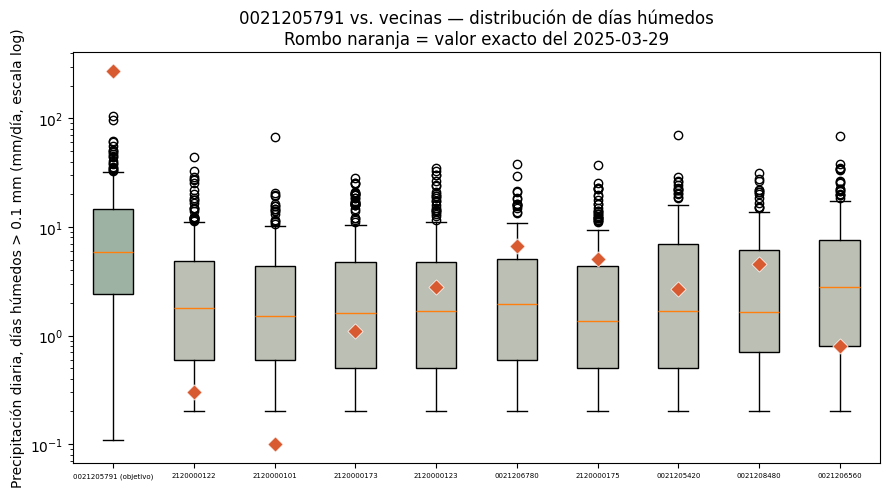

In [ ]:
#Distribución de días húmedos del cluster #3
umbral_humedo = 0.1  # mm/día

estaciones_comparar = [codigo_objetivo] + miembros_cluster
fecha_pico = pd.Timestamp('2025-03-29')

datos_boxplot = []
valores_ese_dia = []
etiquetas = []

for codigo in estaciones_comparar:
    serie = series_diarias.get(codigo)
    if serie is None:
        continue
    dias_humedos = serie[serie > umbral_humedo].dropna()
    datos_boxplot.append(dias_humedos.values)
    valores_ese_dia.append(serie.get(fecha_pico, np.nan))
    etiquetas.append(codigo + (' (objetivo)' if codigo == codigo_objetivo else ''))

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(datos_boxplot, tick_labels=etiquetas, showfliers=True,
                 patch_artist=True, widths=0.5)
for patch, codigo in zip(bp['boxes'], estaciones_comparar):
    patch.set_facecolor('#9EB2A4' if codigo == codigo_objetivo else '#BBBFB4')

# El valor puntual del 2025-03-29, marcado aparte
for i, valor in enumerate(valores_ese_dia, start=1):
    if pd.notna(valor):
        ax.scatter(i, valor, color='#D85A30' if valor > 0 else '#888780',
                   s=60, zorder=5, marker='D', edgecolor='white', linewidth=0.5)

ax.set_yscale('log')
ax.set_ylabel('Precipitación diaria, días húmedos > 0.1 mm (mm/día, escala log)')
ax.set_title(f'{codigo_objetivo} vs. vecinas — distribución de días húmedos\n'
             f'Rombo naranja = valor exacto del {fecha_pico.date()}')
plt.xticks(ha='center', fontsize=5)

plt.tight_layout()
plt.show()

De ahí se ve algo más específico que "corre más alto en promedio": el rombo naranja del 2025-03-29 no solo está por encima de las 9 vecinas ese mismo día, está por encima incluso de los propios valores atípicos históricos de la estación (valores que llegan hasta ~90-100 mm). Eso ya distingue este día como algo cualitativamente distinto del comportamiento normal de la estación, no solo un día lluvioso más.

**Con esa pista, se inspecciona el registro sub-horario del 29 de marzo contra un día típico de la misma estación.**

Total del día 29 de marzo: 274.3 mm
Máximo individual: 3.600 mm — participación: 1.3%
Registros no-cero: 151 de 863 (17.5% del día con algo de actividad)


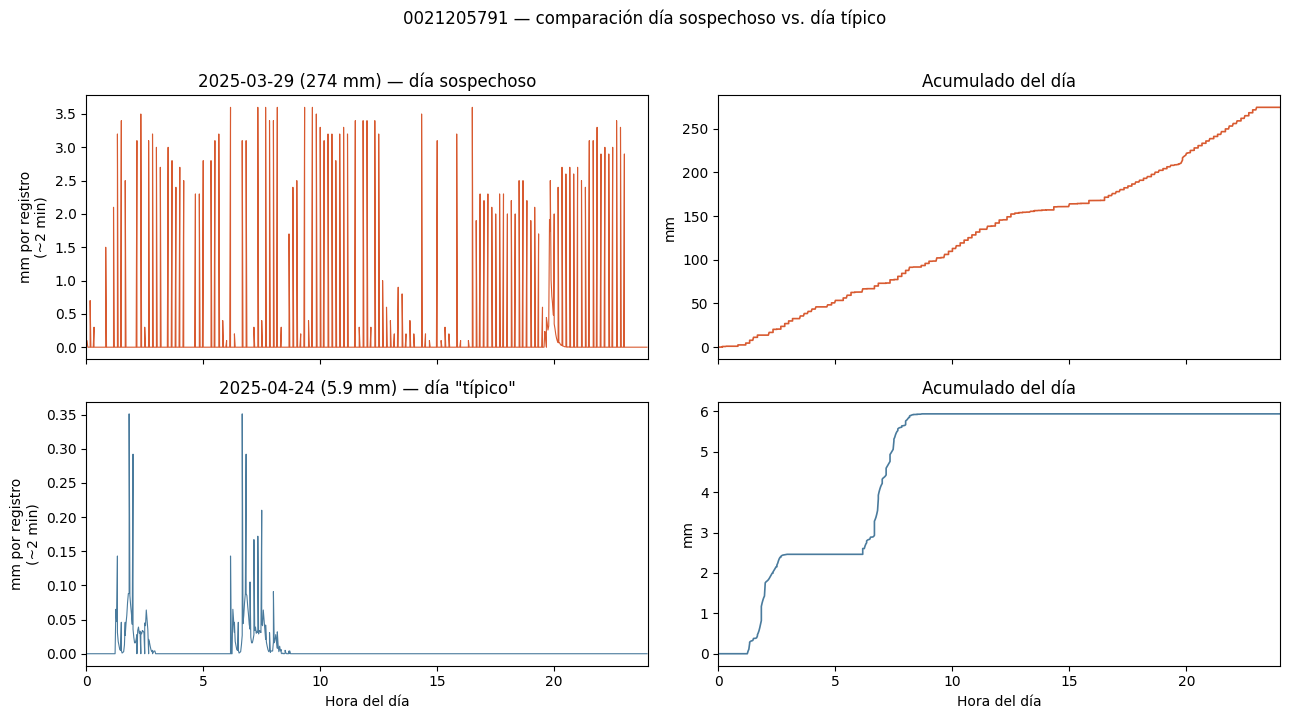

In [ ]:
# Comparación de comportamiento de dos días diferentes de la estación El Dorado
ruta = os.path.join(RUTA_BASE, '0021205791.csv')
df_estacion = pd.read_csv(ruta)
df_estacion['fechaobservacion'] = pd.to_datetime(df_estacion['fechaobservacion'])
df_estacion['fecha'] = df_estacion['fechaobservacion'].dt.date

# Números exactos del 29 de marzo
dia_29 = df_estacion[df_estacion['fecha'] == pd.Timestamp('2025-03-29').date()].sort_values('fechaobservacion')
total_29 = dia_29['valorobservado'].sum()
n_no_cero = (dia_29['valorobservado'] > 0).sum()
print(f"Total del día 29 de marzo: {total_29:.1f} mm")
print(f"Máximo individual: {dia_29['valorobservado'].max():.3f} mm — participación: {dia_29['valorobservado'].max()/total_29*100:.1f}%")
print(f"Registros no-cero: {n_no_cero} de {len(dia_29)} ({n_no_cero/len(dia_29)*100:.1f}% del día con algo de actividad)")

# Día "típico" de la misma estación, para comparar
serie_estacion = series_diarias['0021205791']
dias_humedos = serie_estacion[serie_estacion > umbral_humedo]
mediana = dias_humedos.median()
fecha_normal = (dias_humedos.drop(pd.Timestamp('2025-03-29')) - mediana).abs().idxmin()
dia_normal = df_estacion[df_estacion['fecha'] == fecha_normal.date()].sort_values('fechaobservacion')
total_normal = dia_normal['valorobservado'].sum()

# --- Una sola figura: 2x2 — curva y acumulado, día sospechoso arriba, día típico abajo ---
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

hora_29 = dia_29['fechaobservacion'].dt.hour + dia_29['fechaobservacion'].dt.minute / 60
hora_normal = dia_normal['fechaobservacion'].dt.hour + dia_normal['fechaobservacion'].dt.minute / 60

axes[0, 0].plot(hora_29, dia_29['valorobservado'], lw=0.8, color='#D85A30')
axes[0, 0].set_title(f'2025-03-29 ({total_29:.0f} mm) — día sospechoso')
axes[0, 0].set_ylabel('mm por registro\n(~2 min)')

axes[0, 1].plot(hora_29, dia_29['valorobservado'].cumsum(), lw=1.2, color='#D85A30')
axes[0, 1].set_title('Acumulado del día')
axes[0, 1].set_ylabel('mm')

axes[1, 0].plot(hora_normal, dia_normal['valorobservado'], lw=0.8, color='#4A7B9D')
axes[1, 0].set_title(f'{fecha_normal.date()} ({total_normal:.1f} mm) — día "típico"')
axes[1, 0].set_ylabel('mm por registro\n(~2 min)')
axes[1, 0].set_xlabel('Hora del día')

axes[1, 1].plot(hora_normal, dia_normal['valorobservado'].cumsum(), lw=1.2, color='#4A7B9D')
axes[1, 1].set_title('Acumulado del día')
axes[1, 1].set_ylabel('mm')
axes[1, 1].set_xlabel('Hora del día')

for ax in axes.flat:
    ax.set_xlim(0, 24)

fig.suptitle('0021205791 — comparación día sospechoso vs. día típico', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

El contraste es claro: el día típico (2025-04-24, 5.9 mm) muestra dos ráfagas cortas con forma de subida y bajada — compatible con la escala convectiva de ~3 horas documentada para la Sabana (Casallas-García et al., 2023). El 29 de marzo (274 mm), en cambio, muestra picos regulares de magnitud casi constante durante prácticamente 22 horas seguidas, sin la forma de una tormenta real. El acumulado del día lo confirma: sube en escalera sostenida durante todo el día, no en un salto puntual que señalaría un solo valor mal registrado.

**Esa forma lleva a preguntar si el 29 de marzo fue un caso único o parte de un patrón recurrente de esta estación.** Se buscaron días con más de 15 horas de actividad sub-horaria seguida (muy por encima de las ~3h esperadas):

In [92]:
df_estacion['fecha'] = df_estacion['fechaobservacion'].dt.date
df_estacion['hora'] = df_estacion['fechaobservacion'].dt.floor('h')

horas_activas_por_dia = (
    df_estacion[df_estacion['valorobservado'] > 0]
    .groupby('fecha')['hora'].nunique()
)

# Convección real dura ~3h (Casallas-García et al.) — días con muchas más
# horas de actividad que eso son candidatos a goteo mecánico, no tormenta
sospechosos = horas_activas_por_dia[horas_activas_por_dia > 15].sort_values(ascending=False)
print(f"{len(sospechosos)} de {len(horas_activas_por_dia)} días con >15 horas de actividad seguidas")
print(sospechosos.head(10))

5 de 230 días con >15 horas de actividad seguidas
fecha
2025-03-29    24
2025-04-26    18
2025-05-20    18
2025-05-03    16
2025-06-24    16
Name: hora, dtype: int64


El resultado da una minoría pequeña (5 de 230 días), no un patrón que domine la vida de la estación indica que el sensor no está roto todo el tiempo, falla en episodios puntuales.

**Con eso, la pregunta clave: ¿esos 5 episodios explican por completo la elevación sistemática de P95, o hay algo más de fondo?**

In [90]:
serie_sin_outlier = series_diarias['0021205791'].drop(pd.Timestamp('2025-03-29'))
p95_sin_outlier = serie_sin_outlier.quantile(0.95)
p95_vecinas_valor = df_temporadas.loc[df_temporadas['codigo'] == '0021205791', 'p95_cluster_prom'].values[0]

print(f"P95 CON el 29 de marzo: {df_temporadas.loc[df_temporadas['codigo']=='0021205791', 'p95_propia'].values[0]:.2f}")
print(f"P95 SIN el 29 de marzo: {p95_sin_outlier:.2f}")
print(f"P95 promedio de vecinas: {p95_vecinas_valor:.2f}")

P95 CON el 29 de marzo: 32.42
P95 SIN el 29 de marzo: 32.32
P95 promedio de vecinas: 9.96


La respuesta es que no la explican: el P95 apenas se mueve al remover los 5 días de actividad anómala (32.42 → 31.04), y sigue más de 3 veces el promedio de su cluster. Esto separa el problema en dos hallazgos independientes, no uno solo: (1) episodios puntuales de goteo mecánico identificables y corregibles, y (2) una elevación sistemática de fondo que persiste sin ellos y que no se explica por esos episodios.

**Se descartaron, además, las explicaciones alternativas disponibles**: altitud (2547 m, dentro del rango normal de la red — sin respaldo orográfico) y tecnología (sensor catalogado como automático puro, sin la etiqueta "Convencional").

***Conclusión: `0021205791` (El Dorado) se excluye del dataset final de ground truth.*** La ubicación (aeropuerto El Dorado) ofrece un mecanismo físico plausible — vibración mecánica del entorno aeroportuario afectando el balancín del pluviómetro — consistente con toda la evidencia reunida: picos regulares no convectivos, elevación persistente incluso sin los episodios más extremos, y ausencia de explicaciones alternativas.

#### Criterio #2, Contaminación física (-excluir-):

Se excluye una estación cuando existe (a) un mecanismo físico de contaminación identificable, no relacionado con precipitación, y (b) la anomalía estadística persiste después de remover los episodios puntuales corregibles.

```python
estaciones_excluidas = ['0021205791']  # El Dorado — contaminación por vibración, ver Sección 3.4.1
codigos_finales = [c for c in df_temporadas['codigo'] if c not in estaciones_excluidas]
print(f"{len(codigos_finales)} estaciones en el dataset final (de {len(df_temporadas)})")
```

In [108]:
estaciones_excluidas = ['0021205791']  # El Dorado — contaminación por vibración, ver Sección 3.3.3.1
codigos_finales = [c for c in df_temporadas['codigo'] if c not in estaciones_excluidas]
print(f"{len(codigos_finales)} estaciones en el dataset final (de {len(df_temporadas)})")

df_temporadas_final = df_temporadas[df_temporadas['codigo'].isin(codigos_finales)].copy()

65 estaciones en el dataset final (de 66)


#### 3.3.4 LA LA LAND

In [109]:
print(df_temporadas_final['ratio_p95_cluster'].describe())

count    63.000000
mean      0.982381
std       0.414728
min       0.380000
25%       0.750000
50%       0.910000
75%       1.105000
max       3.420000
Name: ratio_p95_cluster, dtype: float64


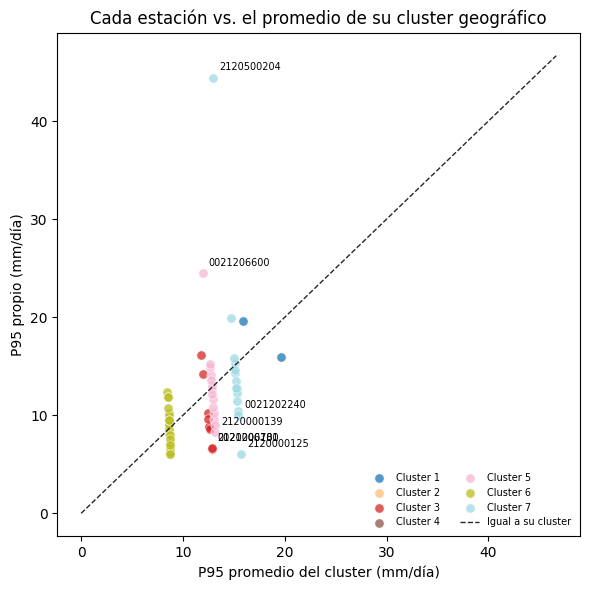

7 estación(es) etiquetada(s) como outlier (ratio > 1.5 o < 0.67):


,codigo,nombre,cluster_geografico,ratio_p95_cluster
34,2120500204,IDEAM PUENTE ARANDA [2120500204],7,3.42
54,0021206600,NUEVA GENERACION [21206600],5,2.05
49,0021202240,UAN SEDE CIRCUNVALAR - AUT [21202240],7,0.65
6,2120000139,ESC. PEDAGOGICA EXPRIMENTAL [2120000139],5,0.63
12,0021206780,LA INDEPENDENCI - AUT [21206780],3,0.52
2,2120000101,ALTOS DE LA ESTANCIA [2120000101],3,0.51
27,2120000125,COLEGIO SORRENTO (SEDE B SAN RAFAEL) (IED) [2...,7,0.38


In [113]:
umbral_outlier = 1.5  # ratio por encima o por debajo de este valor respecto a su cluster

fig, ax = plt.subplots(figsize=(6, 6))

for cluster_id, grupo in df_temporadas_final.groupby('cluster_geografico'):
    color = colores_cluster.get(cluster_id, '#888780')
    ax.scatter(grupo['p95_cluster_prom'], grupo['p95_propia'],
               color=color, alpha=0.75, s=45, edgecolor='white', linewidth=0.5,
               label=f'Cluster {int(cluster_id)}')

lim = max(df_temporadas_final['p95_propia'].max(), df_temporadas_final['p95_cluster_prom'].max()) * 1.05
ax.plot([0, lim], [0, lim], color='#262626', lw=1, linestyle='--', label='Igual a su cluster')

# Etiquetar solo las que se alejan claramente de su cluster (ratio > 1.5 o < 1/1.5)
outliers = df_temporadas_final[
    (df_temporadas_final['ratio_p95_cluster'] > umbral_outlier) |
    (df_temporadas_final['ratio_p95_cluster'] < 1 / umbral_outlier)
]
for _, fila in outliers.iterrows():
    ax.annotate(fila['codigo'], (fila['p95_cluster_prom'], fila['p95_propia']),
                fontsize=7, ha='left', va='bottom', xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('P95 promedio del cluster (mm/día)')
ax.set_ylabel('P95 propio (mm/día)')
ax.set_title('Cada estación vs. el promedio de su cluster geográfico')
ax.legend(fontsize=7, frameon=False, loc='lower right', ncol=2)

plt.tight_layout()
plt.show()

print(f"{len(outliers)} estación(es) etiquetada(s) como outlier (ratio > {umbral_outlier} o < {1/umbral_outlier:.2f}):")
display(outliers[['codigo', 'nombre', 'cluster_geografico', 'ratio_p95_cluster']].sort_values('ratio_p95_cluster', ascending=False))

##### 3.3.4.1 Revisión individual: `2120500204` (IDEAM Puente Aranda)

El perfil resumen ubicó a esta estación como la más extrema de la red en `ratio_p95_cluster` (3.42) y con un segundo valor histórico casi igual al máximo (`ratio_max_segundo_max` = 1.14) — a diferencia de un pico aislado, esto señalaba múltiples días extremos, no uno solo.

**El análisis por temporada (ciclo completo 2024-2025, no solo MAM/SON) confirmó que el problema no está acotado a un evento puntual:** la estación aparece por encima de su cluster geográfico (7) en 4 de las 8 temporadas del ciclo — `JJA_24`, `DEF_25` (el bloque más extremo, incluye el máximo histórico de 651.6 mm el 2025-01-22), `MAM_25`, y `SON_25` en P95. Solo `SON_24` se comporta de forma normal frente al resto del cluster; `DEF_24` y `MAM_24` tienen cobertura insuficiente (0% y 27.2% respectivamente) para evaluar.

**A diferencia de `0021205791` (El Dorado), no se identificó un mecanismo físico de contaminación confirmado.** La estación está ubicada en Puente Aranda, una localidad de uso industrial denso en Bogotá — un entorno donde la vibración mecánica (la misma hipótesis que explicó a El Dorado) es plausible, pero el catálogo no ofrece el nivel de detalle de ubicación necesario para confirmarlo con la misma certeza. Su cadencia de reporte es inestable a través de las temporadas (29.6 → 6.3 → 12.0 → 10.7 min), consistente con comportamiento de instrumento irregular, pero sin la firma sub-horaria específica (picos regulares no convectivos) que sí se verificó directamente para El Dorado.

**Decisión: se excluye del dataset final**, con un estándar de evidencia distinto al de El Dorado — no por mecanismo físico confirmado, sino por anomalía estadística sistemática y recurrente en la mayoría de las temporadas del ciclo, sin explicación climática ni orográfica plausible (altitud de 2559 m, dentro del rango normal de la red).

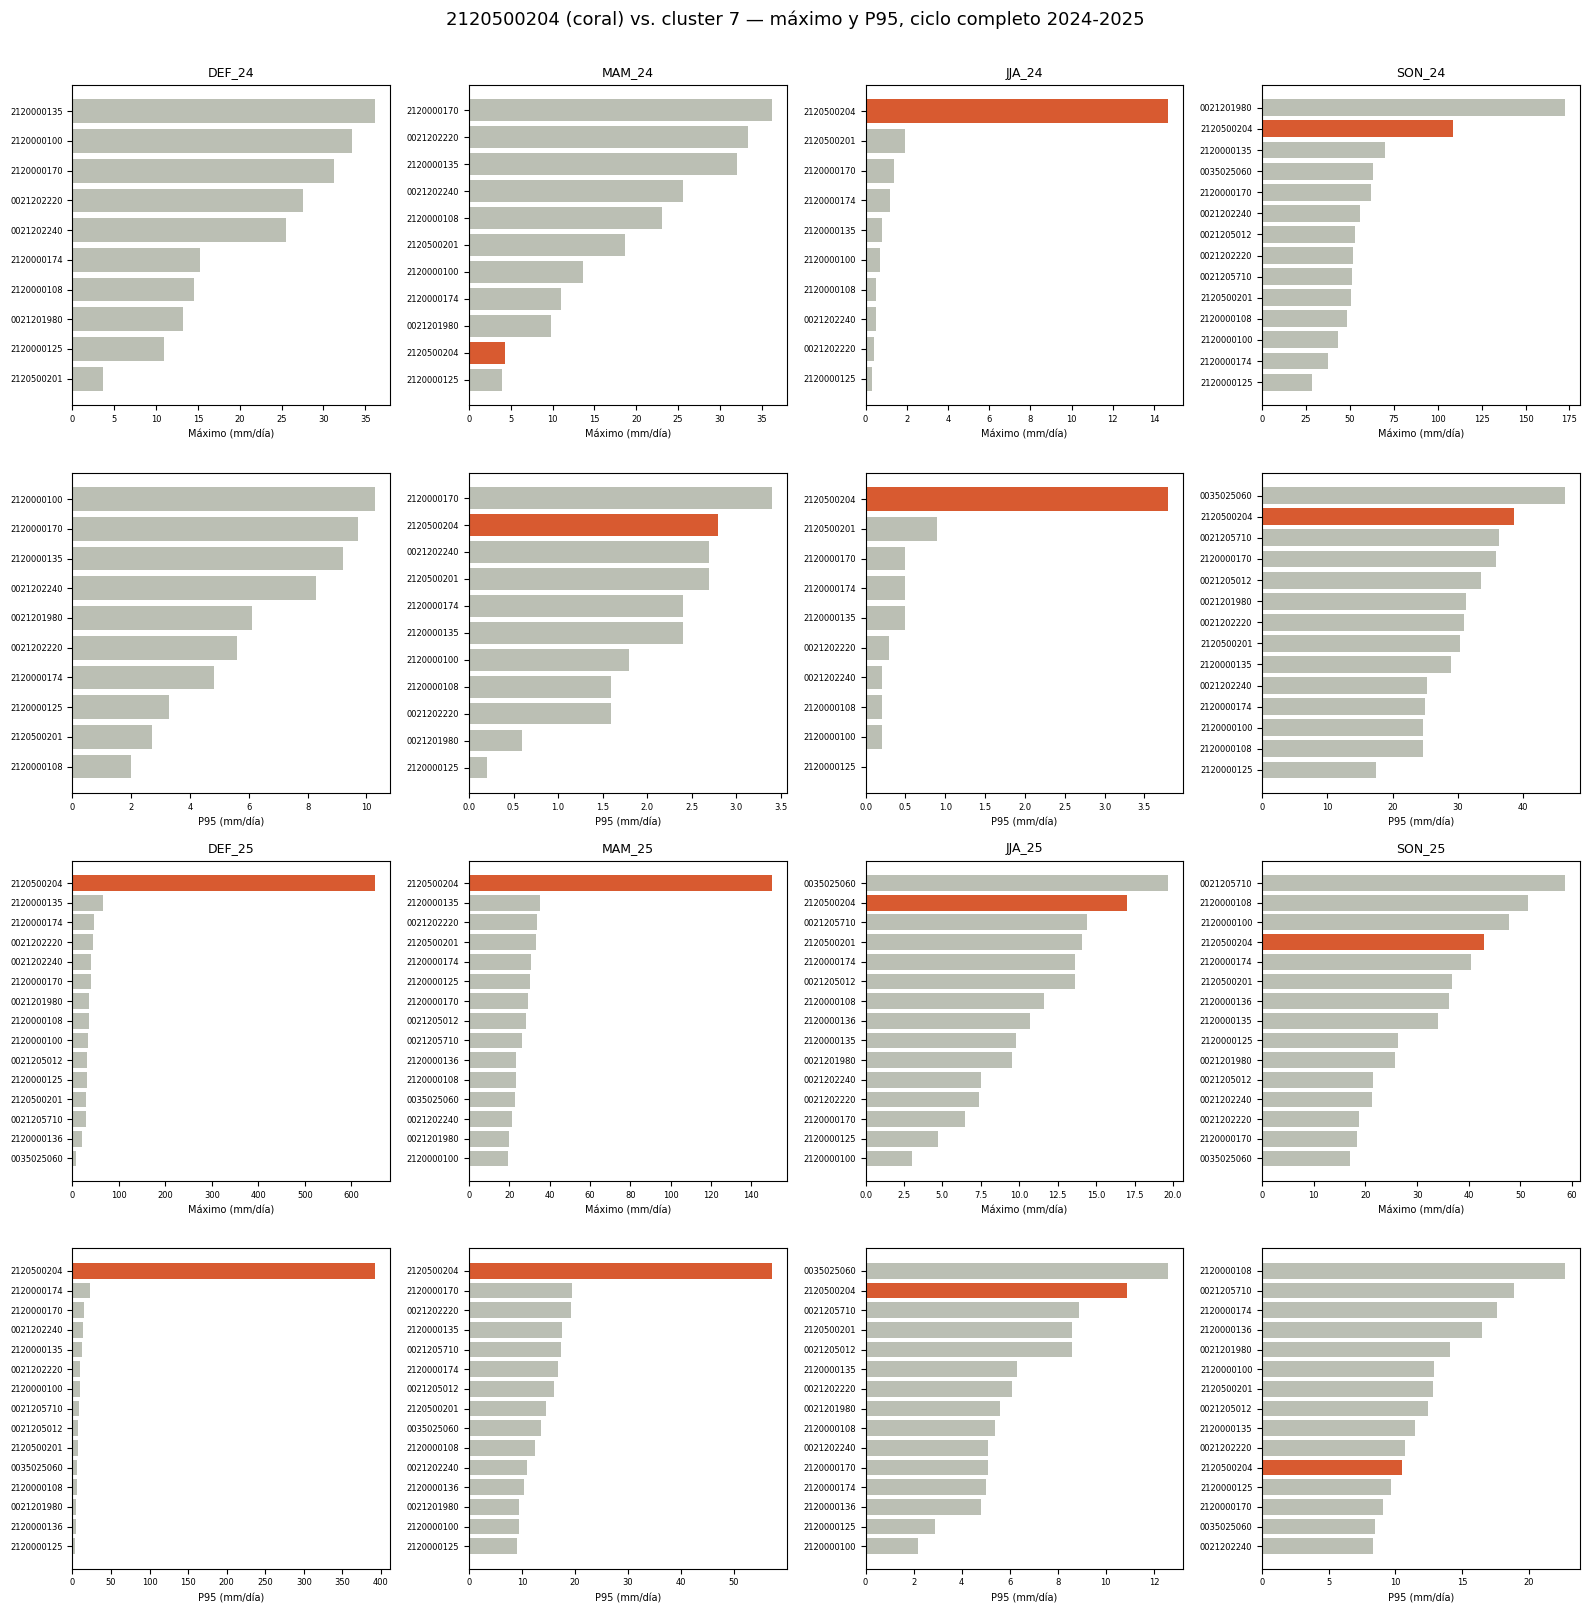

In [ ]:
# Zoom sobre 2120500204
BANDAS_COMPLETAS = {
    'DEF_24': ('2023-12-01', '2024-03-01'),  # sin datos previos a ene-2024 — quedará con muy pocos o ningún punto
    'MAM_24': ('2024-03-01', '2024-06-01'),
    'JJA_24': ('2024-06-01', '2024-09-01'),
    'SON_24': ('2024-09-01', '2024-12-01'),
    'DEF_25': ('2024-12-01', '2025-03-01'),  # esta es la que captura dic-2024/ene-2025 completo
    'MAM_25': ('2025-03-01', '2025-06-01'),
    'JJA_25': ('2025-06-01', '2025-09-01'),
    'SON_25': ('2025-09-01', '2025-12-01'),
}

tabla_pa_completa = tabla_extremos_cluster(cluster_id=7, codigo_objetivo='2120500204', bandas=BANDAS_COMPLETAS)

temporadas_orden = list(BANDAS_COMPLETAS.keys())
metricas = [('max', 'Máximo (mm/día)'), ('p95', 'P95 (mm/día)')]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for bloque in range(2):  # bloque 0: primeras 4 temporadas, bloque 1: últimas 4
    temporadas_bloque = temporadas_orden[bloque * 4:(bloque + 1) * 4]
    for fila_idx, (sufijo, etiqueta_x) in enumerate(metricas):
        fila_grilla = bloque * 2 + fila_idx
        for col_idx, temporada in enumerate(temporadas_bloque):
            ax = axes[fila_grilla, col_idx]
            columna = f'{temporada}_{sufijo}'
            datos = tabla_pa_completa[['codigo', columna, 'objetivo']].dropna(subset=[columna]).sort_values(columna, ascending=True)
            colores = ['#D85A30' if obj else '#BBBFB4' for obj in datos['objetivo']]

            ax.barh(datos['codigo'], datos[columna], color=colores)
            ax.tick_params(labelsize=6)
            ax.set_xlabel(etiqueta_x, fontsize=7)

            if fila_idx == 0:
                ax.set_title(temporada, fontsize=9)

fig.suptitle('2120500204 (coral) vs. cluster 7 — máximo y P95, ciclo completo 2024-2025', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

##### Criterio #3, Anomalía no explicada (-excluir-)

Se excluye una estación cuando presenta anomalía estadística sistemática (elevación frente a su cluster geográfico) recurrente en la mayoría de las temporadas del ciclo anual, sin mecanismo físico de contaminación confirmado ni explicación climática/orográfica alternativa disponible. 

Este criterio exige un estándar de evidencia menor que el Criterio #2 (no requiere causa identificada) y debe documentarse explícitamente como tal — la decisión se apoya en el peso acumulado de la evidencia estadística, no en una causa verificada.

```python
estaciones_excluidas = ['0021205791', '2120500204']
codigos_finales = [c for c in df_temporadas['codigo'] if c not in estaciones_excluidas]
print(f"{len(codigos_finales)} estaciones en el dataset final (de {len(df_temporadas)})")
```

In [114]:
perfil_puente_aranda = df_temporadas[df_temporadas['codigo'] == '2120500204'][
    ['codigo', 'nombre', 'cluster_geografico', 'tecnologia', 'altitud',
     'MAM_24_mean_dias_con_dato', 'SON_24_mean_dias_con_dato', 'MAM_25_mean_dias_con_dato', 'SON_25_mean_dias_con_dato',
     'ratio_p95_cluster', 'ratio_max_segundo_max', 'fecha_max_global', 'precip_max_global', 
     'MAM_24_cadencia_media', 'SON_24_cadencia_media', 'MAM_25_cadencia_media', 'SON_25_cadencia_media']
]
display(perfil_puente_aranda)

,codigo,nombre,cluster_geografico,tecnologia,altitud,MAM_24_mean_dias_con_dato,SON_24_mean_dias_con_dato,MAM_25_mean_dias_con_dato,SON_25_mean_dias_con_dato,ratio_p95_cluster,ratio_max_segundo_max,fecha_max_global,precip_max_global,MAM_24_cadencia_media,SON_24_cadencia_media,MAM_25_cadencia_media,SON_25_cadencia_media
34,2120500204,IDEAM PUENTE ARANDA [2120500204],7,Automática con Telemetría,2559,0.272,0.989,0.935,0.967,3.42,1.14,2025-01-22,651.6,29.6,6.3,12.0,10.7


##### 0021206600 VAMOS AQUÍ

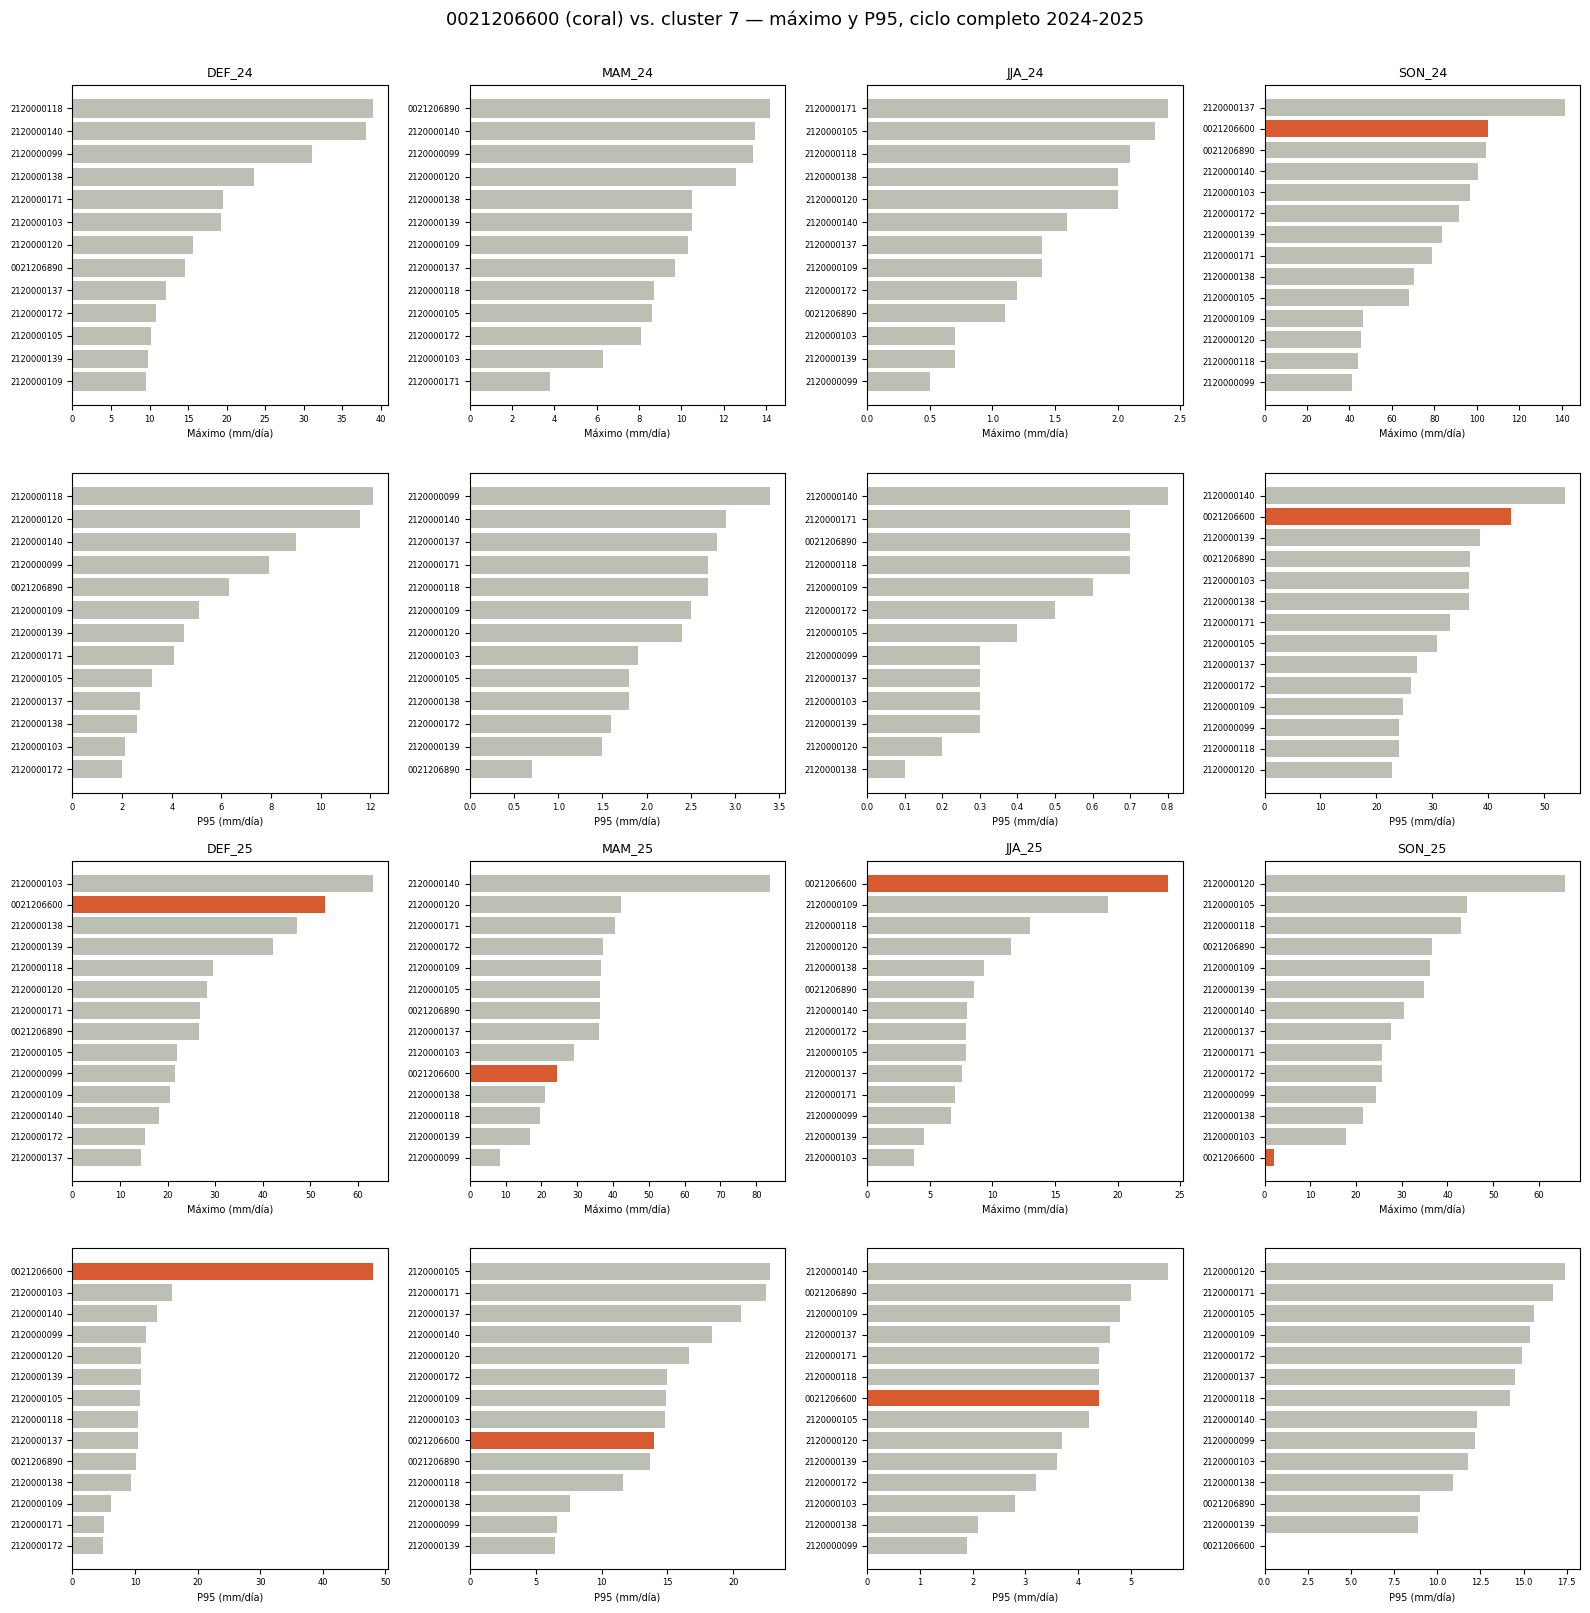

In [137]:
# Zoom sobre 0021206600
BANDAS_COMPLETAS = {
    'DEF_24': ('2023-12-01', '2024-03-01'),  # sin datos previos a ene-2024 — quedará con muy pocos o ningún punto
    'MAM_24': ('2024-03-01', '2024-06-01'),
    'JJA_24': ('2024-06-01', '2024-09-01'),
    'SON_24': ('2024-09-01', '2024-12-01'),
    'DEF_25': ('2024-12-01', '2025-03-01'),  # esta es la que captura dic-2024/ene-2025 completo
    'MAM_25': ('2025-03-01', '2025-06-01'),
    'JJA_25': ('2025-06-01', '2025-09-01'),
    'SON_25': ('2025-09-01', '2025-12-01'),
}

tabla_pa_completa = tabla_extremos_cluster(cluster_id=5, codigo_objetivo='0021206600', bandas=BANDAS_COMPLETAS)

temporadas_orden = list(BANDAS_COMPLETAS.keys())
metricas = [('max', 'Máximo (mm/día)'), ('p95', 'P95 (mm/día)')]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for bloque in range(2):  # bloque 0: primeras 4 temporadas, bloque 1: últimas 4
    temporadas_bloque = temporadas_orden[bloque * 4:(bloque + 1) * 4]
    for fila_idx, (sufijo, etiqueta_x) in enumerate(metricas):
        fila_grilla = bloque * 2 + fila_idx
        for col_idx, temporada in enumerate(temporadas_bloque):
            ax = axes[fila_grilla, col_idx]
            columna = f'{temporada}_{sufijo}'
            datos = tabla_pa_completa[['codigo', columna, 'objetivo']].dropna(subset=[columna]).sort_values(columna, ascending=True)
            colores = ['#D85A30' if obj else '#BBBFB4' for obj in datos['objetivo']]

            ax.barh(datos['codigo'], datos[columna], color=colores)
            ax.tick_params(labelsize=6)
            ax.set_xlabel(etiqueta_x, fontsize=7)

            if fila_idx == 0:
                ax.set_title(temporada, fontsize=9)

fig.suptitle('0021206600 (coral) vs. cluster 7 — máximo y P95, ciclo completo 2024-2025', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

#### 3.2.3 Aplamiento silencioso

#### 3.2.4 Sistemático alto

#### 3.2.5 Pico aislado

#### 3.2.1 Revisión de homogeneidad

La revisión combinó inspección visual (grilla de 66 series diarias, ordenada
territorialmente N→S/O→E, con sombreado de las temporadas de lluvia MAM/SON)
con tres diagnósticos cuantitativos: razón máximo/segundo-máximo por estación,
consistencia espacial de P95 contra las 5 vecinas geográficas más cercanas
(`cKDTree`), y cobertura de datos por temporada. De ahí surgieron tres
categorías de hallazgos, cada una con una causa probable distinta y un
tratamiento distinto — no se trata de un solo tipo de problema.

**Anomalía sistemática (posible sesgo de instrumento u orográfico)**

`2120500204` (razón P95 vs. vecinas = 3.98), `0021205791` (2.85) y
`0021206600` (2.27) tienen una distribución completa corrida hacia arriba
frente a su entorno geográfico — no es un solo día atípico, es la mayoría de
sus días altos. `0021206560` (1.89) queda en zona limítrofe y se agrupa con
estas tres para revisión conjunta. **Pendiente:** confirmar contra el campo
`altitud` de `df_catalogo_gt` antes de tratarlas como sospechosas de
instrumento — el terreno de cordillera puede producir el mismo patrón por
efecto orográfico legítimo.

**Pico aislado de un solo día (sin arrastre en la distribución)**

`2306500204`, `2120000137` y `0021201980` muestran una aguja dramática en la
grilla, pero no aparecen entre las estaciones con P95 alto — su distribución
general es normal frente a sus vecinas. Esto descarta que sea el mismo
problema que las anteriores: es un evento puntual, no un sesgo de toda la
serie. **Pendiente:** chequeo de fecha-contra-vecinas (¿otras estaciones
cercanas registran algo elevado ese mismo día?) para diferenciar tormenta
regional real de dato roto.

**Hueco de cobertura en 2024 (13 estaciones, funcionalmente solo-prueba)**

El sombreado MAM/SON, cuantificado después con `% de días con dato por
temporada`, mostró que el déficit de 2024 (media 0.73-0.75 vs. 0.93-0.94 en
2025) no está repartido parejo en la red — está concentrado en un subgrupo:

| Código | MAM 2024 | SON 2024 |
|---|---|---|
| 0021205910, 2306500204, 2120500135, 0021206600, 0021205791, 0021205420, 0021205710, 0021206280, 0021205012, 0021206560, 0035025060 | 0.00 | 0.27–0.46 |
| 2120000136 | 0.00 | 0.00 |
| 2120500204 | 0.27 | 0.99 |

El resto de la red (53 estaciones) tiene cobertura 2024 razonable
(percentil 25 = 0.82). Estas 13 aportan poco o nada al ajuste del umbral
Weibull sobre 2024, y funcionan de facto como estaciones **solo-prueba**
para 2025 — distinto de "validación" (que en el diseño de la tesis se
refiere a un subconjunto dentro de 2024 para tuning, decisión aún abierta).

**Decisión tomada:** no se excluye ninguna estación del QC ni del dataset en
esta etapa por tener cobertura parcial — se documentan para tratamiento
diferenciado más adelante, ya que un problema no detectado en su

In [17]:
# 1) Candidatas a "aguja aislada": el máximo vs. el resto de su propia serie
resumen = []
for codigo, serie in series_diarias.items():
    valores = np.sort(serie.values)[::-1]
    maximo, segundo_max = valores[0], valores[1] if len(valores) > 1 else np.nan
    resumen.append({
        'codigo': codigo,
        'maximo': maximo,
        'razon_max_segundo': maximo / segundo_max if segundo_max > 0 else np.nan,
        'fecha_max': serie.idxmax()
    })
df_resumen = pd.DataFrame(resumen).sort_values('razon_max_segundo', ascending=False)
df_resumen.head(15)

# 2) ¿Las fechas de máximo se agrupan en el tiempo? (evidencia de tormenta real vs. artefactos dispersos)
df_resumen.groupby(pd.Grouper(key='fecha_max', freq='W')).size().sort_values(ascending=False).head(10)

# 3) Consistencia espacial: cada estación contra sus k vecinas geográficas más cercanas
coords_arr = coords[['latitud', 'longitud']].values
tree = cKDTree(coords_arr)
k = 5
dist, idx = tree.query(coords_arr, k=k + 1)

resultado_espacial = []
for i, codigo in enumerate(coords['codigo']):
    vecinas = coords['codigo'].iloc[idx[i, 1:]].tolist()
    p95_propia = series_diarias[codigo].quantile(0.95)
    p95_vecinas = np.mean([series_diarias[v].quantile(0.95) for v in vecinas if v in series_diarias])
    resultado_espacial.append({
        'codigo': codigo, 'p95_propia': p95_propia,
        'p95_vecinas_prom': p95_vecinas,
        'razon': p95_propia / p95_vecinas if p95_vecinas > 0 else np.nan
    })
pd.DataFrame(resultado_espacial).sort_values('razon', ascending=False)

,codigo,p95_propia,p95_vecinas_prom,razon
34,2120500204,44.440,11.1630,3.981009
50,0021205791,32.424,11.3950,2.845459
54,0021206600,24.495,10.8020,2.267636
57,0021206560,16.100,8.4980,1.894563
62,0021205710,19.920,12.9370,1.539770
...,...,...,...,...
3,2120000173,10.270,15.6608,0.655777
42,2120000175,8.560,13.5020,0.633980
36,2120000099,9.040,14.5530,0.621178
6,2120000139,8.280,13.4190,0.617036


**Cómo leer la grilla:** buscar visualmente (i) saltos de nivel que no coincidan con un evento de lluvia conocido en la Sabana, (ii) tramos planos prolongados que no sean simplemente temporada seca, y (iii) cualquier patrón que se vea claramente distinto al resto — el objetivo es identificar candidatas para revisión puntual, no auditar las 66 en detalle.

Anotar aquí las estaciones marcadas para seguimiento tras revisar la grilla (código + qué se observó):

- *(pendiente de completar tras la inspección visual)*

In [ ]:
# Chequeo automático de apoyo: tramos de valores diarios idénticos y distintos de cero,
# que podrían indicar un sensor atascado (no un día seco, que reportaría 0)
def detectar_tramos_constantes(serie, min_dias=5):
    """Detecta corridas de al menos `min_dias` consecutivos con el mismo valor > 0."""
    positivos = serie[serie > 0]
    if len(positivos) == 0:
        return pd.DataFrame()
    cambios = positivos.diff().fillna(1) != 0
    grupo = cambios.cumsum()
    tramos = positivos.groupby(grupo).agg(['count', 'first'])
    return tramos[tramos['count'] >= min_dias]

print("Estaciones con tramos de ≥5 días consecutivos con precipitación diaria idéntica (>0):\n")
alguna_sospechosa = False
for codigo, serie in series_diarias.items():
    sospechosos = detectar_tramos_constantes(serie)
    if len(sospechosos) > 0:
        alguna_sospechosa = True
        print(f"  {codigo}: {len(sospechosos)} tramo(s) sospechoso(s)")
        print(sospechosos)

if not alguna_sospechosa:
    print("  Ninguna estación muestra tramos constantes sospechosos con este criterio.")

## N. Cómo llueve!

1. Control de calidad de las 66 estaciones (antes de calcular nada)

- Inspección visual rápida de cada serie: saltos abruptos, tramos sospechosamente planos, cambios de precisión decimal.
- Si alguna estación se ve rara, contrastarla contra estaciones vecinas o contra la señal satelital de esa misma hora.
- Verificar la resolución decimal real de los pluviómetros — necesario para validar si 0.1 mm/h tiene sentido como corte de hora húmeda, o si hace falta ajustarlo.

In [28]:
# Cargar lista de estaciones seleccionadas
estaciones_gt = pd.read_csv('estaciones_ground_truth.csv', dtype={'estacion': str})
codigos_gt = set(estaciones_gt['estacion'])
print(f"Estaciones a cargar: {len(codigos_gt)}")

# Cargar y concatenar todos los CSVs
carpeta = r'..\..\data\rainfall_subhourly'
dfs = []

for archivo in os.listdir(carpeta):
    if archivo.endswith('.csv'):
        cod = archivo.replace('.csv', '')
        if cod in codigos_gt:
            df = pd.read_csv(
                os.path.join(carpeta, archivo),
                dtype={'codigoestacion': str}
            )
            dfs.append(df)

df_precip = pd.concat(dfs, ignore_index=True)

# Convertir tipos
df_precip['fechaobservacion'] = pd.to_datetime(df_precip['fechaobservacion'])
df_precip['valorobservado'] = pd.to_numeric(df_precip['valorobservado'], errors='coerce')

print(f"Total registros cargados: {len(df_precip):,}")
print(f"Estaciones únicas: {df_precip['codigoestacion'].nunique()}")
print(f"Rango de fechas: {df_precip['fechaobservacion'].min()} a {df_precip['fechaobservacion'].max()}")

Estaciones a cargar: 66
Total registros cargados: 28,907,285
Estaciones únicas: 66
Rango de fechas: 2024-01-01 09:07:00 a 2025-12-31 23:59:00


In [29]:
# Agregar a horario — sumar mm por estación por hora
df_precip['hora'] = df_precip['fechaobservacion'].dt.floor('h')

df_horario = df_precip.groupby(['codigoestacion', 'hora']).agg(
    precip_mm=('valorobservado', 'sum'),
    n_registros=('valorobservado', 'count')
).reset_index()

print(f"Total filas horarias: {len(df_horario):,}")
print(f"Promedio registros sub-horarios por hora: {df_horario['n_registros'].mean():.1f}")
print(df_horario.head(5))

Total filas horarias: 781,936
Promedio registros sub-horarios por hora: 37.0
  codigoestacion                hora  precip_mm  n_registros
0     0021201980 2024-01-05 13:00:00        0.0           14
1     0021201980 2024-01-05 14:00:00        0.0           17
2     0021201980 2024-01-05 15:00:00        0.0           14
3     0021201980 2024-01-05 16:00:00        0.0           15
4     0021201980 2024-01-05 17:00:00        0.0           17


In [30]:
# Solo horas con lluvia (> 0 mm)
df_lluvia = df_horario[df_horario['precip_mm'] > 0].copy()

print(f"Horas con lluvia: {len(df_lluvia):,} ({len(df_lluvia)/len(df_horario)*100:.1f}% del total)")
print(f"\nDistribución de precipitación horaria (mm/h) — solo horas con lluvia:")
print(df_lluvia['precip_mm'].describe(percentiles=[.5, .75, .90, .95, .99]))

Horas con lluvia: 61,474 (7.9% del total)

Distribución de precipitación horaria (mm/h) — solo horas con lluvia:
count    61474.000000
mean         1.287494
std          3.446821
min          0.001000
50%          0.400000
75%          1.000000
90%          2.800000
95%          5.200000
99%         15.400000
max         94.200000
Name: precip_mm, dtype: float64


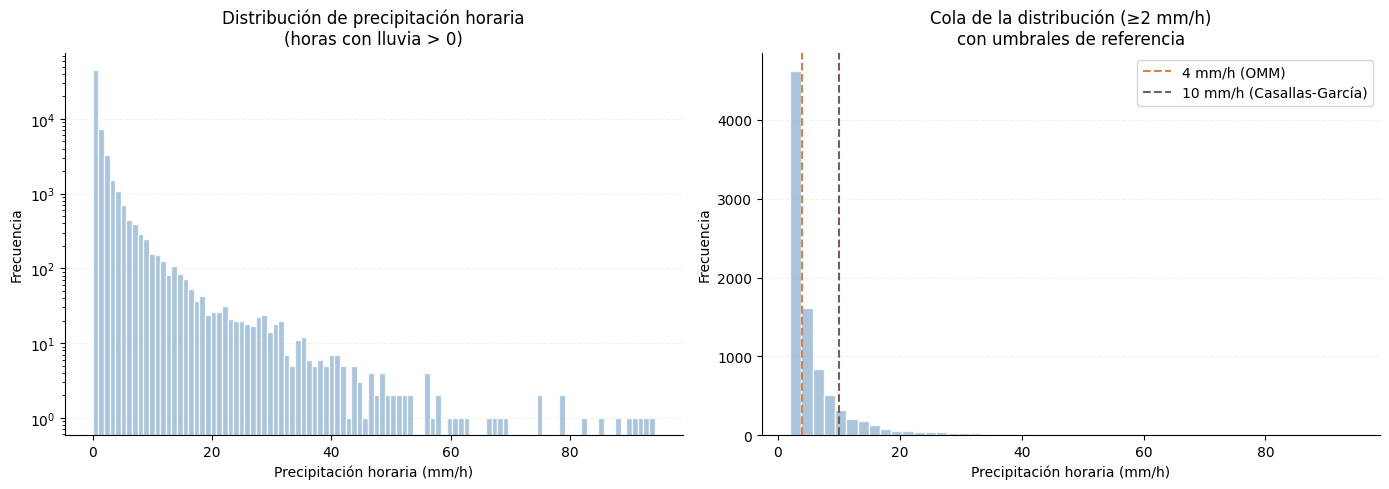

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda — distribución completa en escala log
axes[0].hist(df_lluvia['precip_mm'], bins=100, color='#94B6D2', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Precipitación horaria (mm/h)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de precipitación horaria\n(horas con lluvia > 0)')
axes[0].set_yscale('log')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Derecha — zoom en la cola (> 2 mm/h)
df_cola = df_lluvia[df_lluvia['precip_mm'] >= 2]
axes[1].hist(df_cola['precip_mm'], bins=50, color='#94B6D2', alpha=0.8, edgecolor='white')
for umbral, label, color in [(4, '4 mm/h (OMM)', '#DD8047'), 
                              (10, '10 mm/h (Casallas-García)', '#775F55')]:
    axes[1].axvline(umbral, color=color, linestyle='--', linewidth=1.5, label=label)
axes[1].set_xlabel('Precipitación horaria (mm/h)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Cola de la distribución (≥2 mm/h)\ncon umbrales de referencia')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

for ax in axes:
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [32]:
for umbral in [4, 5, 7, 10]:
    n_positivos = (df_horario['precip_mm'] >= umbral).sum()
    pct = n_positivos / len(df_horario) * 100
    print(f"Umbral {umbral:2d} mm/h: {n_positivos:,} horas positivas ({pct:.2f}% del total)")

Umbral  4 mm/h: 4,241 horas positivas (0.54% del total)
Umbral  5 mm/h: 3,268 horas positivas (0.42% del total)
Umbral  7 mm/h: 2,093 horas positivas (0.27% del total)
Umbral 10 mm/h: 1,253 horas positivas (0.16% del total)


In [33]:
for umbral in [4, 5, 7, 10]:
    horas_positivas = df_horario[df_horario['precip_mm'] >= umbral]['hora'].nunique()
    print(f"Umbral {umbral:2d} mm/h: {horas_positivas:,} horas únicas con al menos una estación positiva")

Umbral  4 mm/h: 1,320 horas únicas con al menos una estación positiva
Umbral  5 mm/h: 1,129 horas únicas con al menos una estación positiva
Umbral  7 mm/h: 865 horas únicas con al menos una estación positiva
Umbral 10 mm/h: 632 horas únicas con al menos una estación positiva


In [34]:
# Probar con una sola estación
df_prueba = df_precip[df_precip['codigoestacion'] == '2120000108'].copy()
df_prueba = df_prueba.sort_values('fechaobservacion').set_index('fechaobservacion')

df_ventana_prueba = (
    df_prueba['valorobservado']
    .rolling('60min', min_periods=1)
    .sum()
    .reset_index()
)
df_ventana_prueba.columns = ['fechaobservacion', 'precip_60min']

print(f"Registros: {len(df_ventana_prueba):,}")
print(df_ventana_prueba[df_ventana_prueba['precip_60min'] > 0].head(10))

Registros: 549,870
        fechaobservacion  precip_60min
1110 2024-01-10 16:14:00           0.1
1111 2024-01-10 16:17:00           0.2
1112 2024-01-10 16:21:00           0.2
1113 2024-01-10 16:24:00           0.2
1114 2024-01-10 16:28:00           0.2
1115 2024-01-10 16:31:00           0.2
1116 2024-01-10 16:41:00           0.3
1117 2024-01-10 16:48:00           0.3
1118 2024-01-10 16:52:00           0.3
1119 2024-01-10 17:05:00           0.3


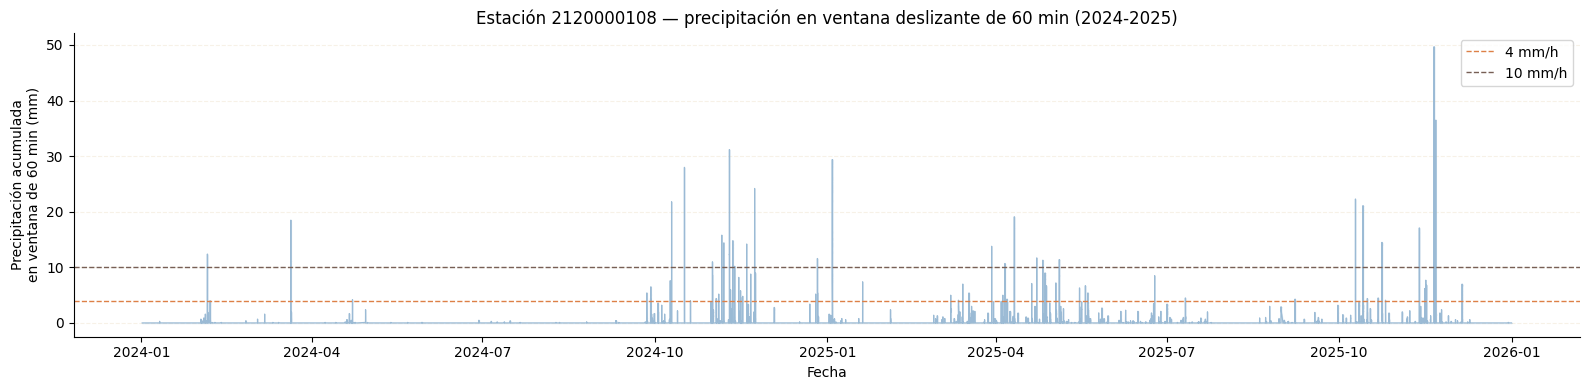

In [36]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(df_ventana_prueba['fechaobservacion'], df_ventana_prueba['precip_60min'],
        color='#94B6D2', linewidth=0.8, alpha=0.9)

ax.fill_between(df_ventana_prueba['fechaobservacion'], df_ventana_prueba['precip_60min'],
                alpha=0.3, color='#94B6D2')

# Líneas de umbral
for umbral, color, label in [(4, '#DD8047', '4 mm/h'), (10, '#775F55', '10 mm/h')]:
    ax.axhline(umbral, color=color, linestyle='--', linewidth=1, label=label)

ax.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
ax.set_axisbelow(True)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precipitación acumulada\nen ventana de 60 min (mm)')
ax.set_title('Estación 2120000108 — precipitación en ventana deslizante de 60 min (2024-2025)', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

Registros con lluvia: 45,009

Distribución precip_60min (mm/h) — solo registros con lluvia:
count    45009.000000
mean         1.745051
std          3.816848
min          0.100000
50%          0.500000
75%          1.400000
90%          4.200000
95%          8.000000
99%         21.000000
max         49.700000
Name: precip_60min, dtype: float64


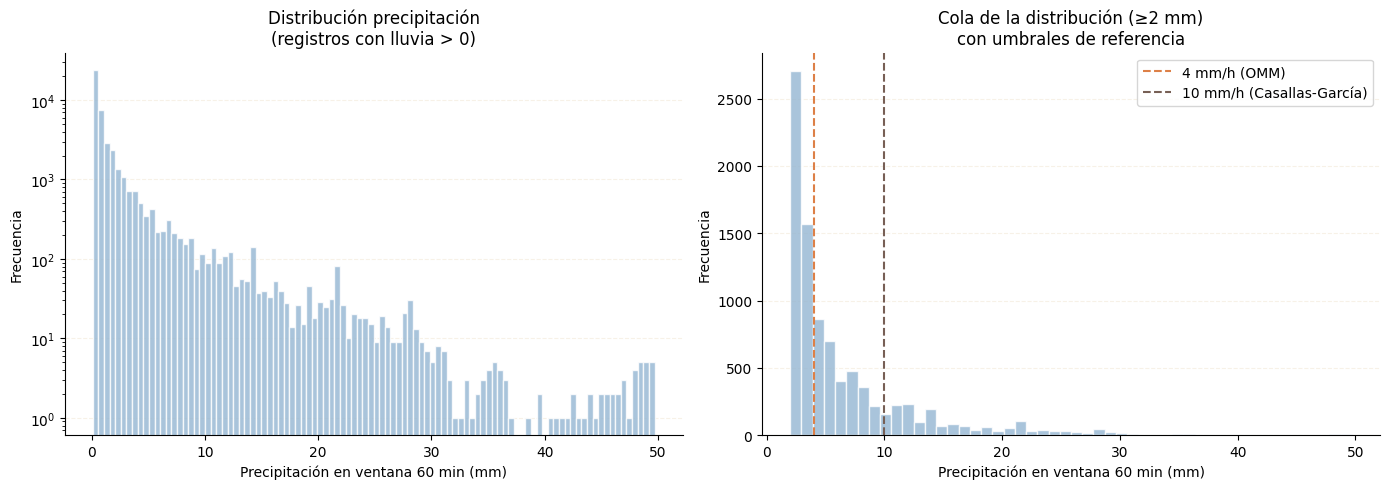

In [37]:
# Ventana deslizante para esta estación ya la tenemos en df_ventana_prueba
df_lluvia_prueba = df_ventana_prueba[df_ventana_prueba['precip_60min'] > 0].copy()

print(f"Registros con lluvia: {len(df_lluvia_prueba):,}")
print(f"\nDistribución precip_60min (mm/h) — solo registros con lluvia:")
print(df_lluvia_prueba['precip_60min'].describe(percentiles=[.5, .75, .90, .95, .99]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda — distribución completa en escala log
axes[0].hist(df_lluvia_prueba['precip_60min'], bins=100, color='#94B6D2', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Precipitación en ventana 60 min (mm)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución precipitación\n(registros con lluvia > 0)')
axes[0].set_yscale('log')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Derecha — cola con umbrales
df_cola_prueba = df_lluvia_prueba[df_lluvia_prueba['precip_60min'] >= 2]
axes[1].hist(df_cola_prueba['precip_60min'], bins=50, color='#94B6D2', alpha=0.8, edgecolor='white')
for umbral, label, color in [(4, '4 mm/h (OMM)', '#DD8047'),
                              (10, '10 mm/h (Casallas-García)', '#775F55')]:
    axes[1].axvline(umbral, color=color, linestyle='--', linewidth=1.5, label=label)
axes[1].set_xlabel('Precipitación en ventana 60 min (mm)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Cola de la distribución (≥2 mm)\ncon umbrales de referencia')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

for ax in axes:
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

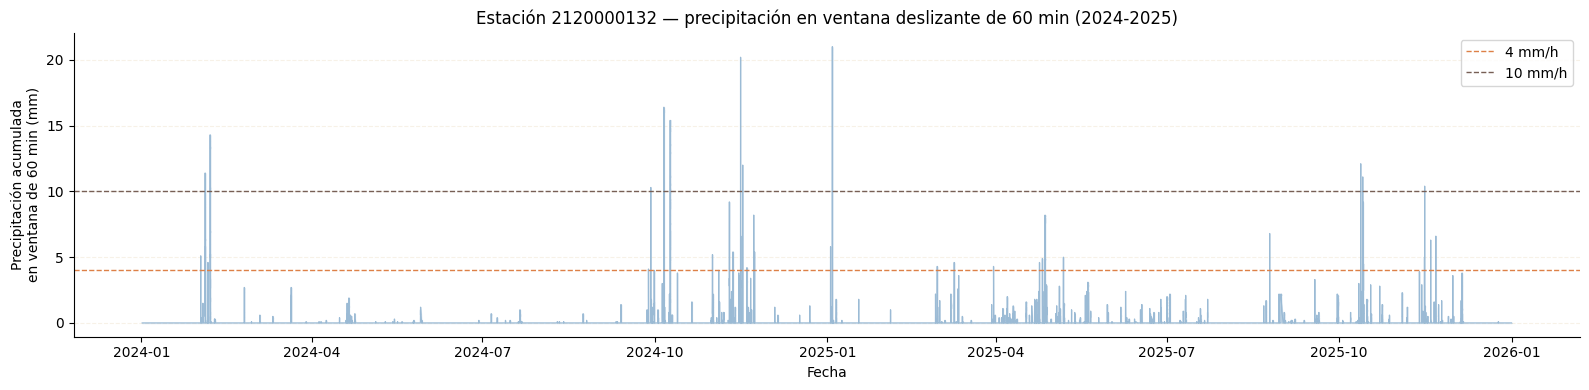

In [41]:
# Probar con una sola estación
df_prueba = df_precip[df_precip['codigoestacion'] == '2120000132'].copy()
df_prueba = df_prueba.sort_values('fechaobservacion').set_index('fechaobservacion')

df_ventana_prueba = (
    df_prueba['valorobservado']
    .rolling('60min', min_periods=1)
    .sum()
    .reset_index()
)
df_ventana_prueba.columns = ['fechaobservacion', 'precip_60min']

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(df_ventana_prueba['fechaobservacion'], df_ventana_prueba['precip_60min'],
        color='#94B6D2', linewidth=0.8, alpha=0.9)

ax.fill_between(df_ventana_prueba['fechaobservacion'], df_ventana_prueba['precip_60min'],
                alpha=0.3, color='#94B6D2')

# Líneas de umbral
for umbral, color, label in [(4, '#DD8047', '4 mm/h'), (10, '#775F55', '10 mm/h')]:
    ax.axhline(umbral, color=color, linestyle='--', linewidth=1, label=label)

ax.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
ax.set_axisbelow(True)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precipitación acumulada\nen ventana de 60 min (mm)')
ax.set_title('Estación 2120000132 — precipitación en ventana deslizante de 60 min (2024-2025)', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

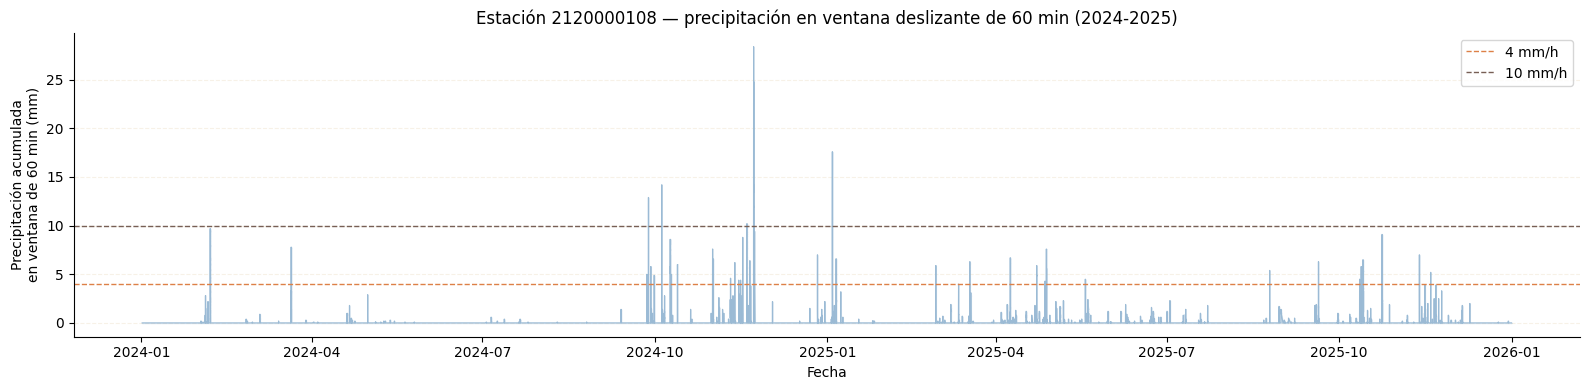

In [ ]:
# Ventana deslizante de 60 minutos
# Para cada registro, suma los mm en los 60 minutos anteriores

df_precip_sorted = df_precip.sort_values(['codigoestacion', 'fechaobservacion']).copy()

# Calcular precipitación acumulada en ventana deslizante de 60 min por estación
df_precip_sorted = df_precip_sorted.set_index('fechaobservacion')

df_ventana = (
    df_precip_sorted
    .groupby('codigoestacion')['valorobservado']
    .rolling('60min', min_periods=1)
    .sum()
    .reset_index()
)

df_ventana.columns = ['codigoestacion', 'fechaobservacion', 'precip_60min']

print(f"Total registros con ventana deslizante: {len(df_ventana):,}")
print(df_ventana.head(5))

In [ ]:
def vecinas_mas_cercanas(codigo, radio_km=20):
    """Todas las estaciones dentro de radio_km — reemplaza el k fijo por el radio de Casallas-García et al. (2023)."""
    radio_deg = radio_km / 111
    idx_estacion = coords_validas.index[coords_validas['codigo'] == codigo][0]
    vecinas_idx = tree.query_ball_point(coords_arr[idx_estacion], r=radio_deg)
    vecinas_idx = [i for i in vecinas_idx if i != idx_estacion]
    return coords_validas['codigo'].iloc[vecinas_idx].tolist()

def cluster_es_vecino(codigos_cluster, radio_km=20):
    resultado = {}
    for codigo in codigos_cluster:
        vecinas = vecinas_mas_cercanas(codigo, radio_km=radio_km)
        resultado[codigo] = [c for c in codigos_cluster if c != codigo and c in vecinas]
    return resultado